# Baseline Anual — Minería del Cobre en Chile

**Propósito:** Establecer un conjunto de modelos de referencia (*baselines*) para la predicción anual de producción de cobre a nivel de mina, usando validación por origen rodante (*rolling-origin*). Estos resultados justifican la complejidad del modelo final (v8c) con segmentación, Optuna y ensambles.

**Datos:** 24 minas activas (excluyendo Spence y Quebrada Blanca), período 1982–2025.  
**Horizontes:** H+1 a H+7 años.  
**Orígenes:** 2010–2018 (9 orígenes, ventana expandible).  
**Target:** LogRatio = log(Prod_{t+h} / Prod_origin). La predicción naive siempre es 0.

## Sección 0 — Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb
import xgboost as xgb

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from pmdarima import auto_arima
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibilidad ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Estilo gráfico ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── Rutas de datos ────────────────────────────────────────────────────────────
DATA_PATH     = '../../../01_Data/processed/produccion_master.csv'
METADATA_PATH = '../../../01_Data/processed/metadata_minas.csv'

# ── Configuración de validación ───────────────────────────────────────────────
MINES_EXCLUDE = ['spence', 'quebrada blanca']   # Match_Key (lowercase) a excluir
ORIGINS       = list(range(2010, 2019))          # 2010 … 2018  (9 orígenes)
HORIZONS      = list(range(1, 8))                # H+1 … H+7
BASE_YEAR     = 2025                             # último año con datos reales
PANDEMIC_YEARS = [2020, 2021]

# ── Mapeo Company_Size (hardcoded según diseño del modelo final) ───────────────
# Los Match_Key están en minúsculas con espacios (tal como aparecen en el CSV)
COMPANY_SIZE = {
    'escondida':                       2,
    'chuquicamata':                    2,
    'el teniente':                     2,
    'andina':                          2,
    'radomiro tomic':                  2,
    'salvador':                        2,
    'ministro hales':                  2,
    'gabriela mistral':                2,
    'collahuasi':                      2,
    'los bronces':                     2,
    'lomas bayas':                     2,
    'cerro colorado':                  2,
    'el abra':                         2,
    'los pelambres':                   1,
    'centinela_centinela_sulfuros_':   1,
    'centinela_centinela_oxidos_':     1,
    'centinela_centinela_óxidos_':     1,  # variante con tilde
    'zaldivar':                        1,
    'antucoya':                        1,
    'andacollo':                       1,
    'candelaria':                      1,
    'caserones':                       1,
    'sierra gorda':                    1,
    'capstone copper (4)':             0,
}

print('Configuración cargada.')
print(f'  Orígenes : {ORIGINS}')
print(f'  Horizontes: H+{HORIZONS[0]} a H+{HORIZONS[-1]}')
print(f'  Minas excluidas: {MINES_EXCLUDE}')

## Sección 1 — Carga de Datos

In [2]:
# ── Carga del dataset maestro ─────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8')
df_raw['Match_Key']    = df_raw['Match_Key'].str.lower().str.strip()
df_raw['Produccion']   = pd.to_numeric(df_raw['Produccion'],   errors='coerce').fillna(0)
df_raw['Capital_Stock']= pd.to_numeric(df_raw['Capital_Stock'],errors='coerce').fillna(0)
df_raw['Precio_Cobre'] = pd.to_numeric(df_raw['Precio_Cobre'], errors='coerce')
df_raw['Precio_Cobre'] = df_raw['Precio_Cobre'].ffill().fillna(method='bfill')
df_raw['Inversion_MMUSD'] = pd.to_numeric(df_raw['Inversion_MMUSD'], errors='coerce').fillna(0)

# Excluir minas
df_raw = df_raw[~df_raw['Match_Key'].isin(MINES_EXCLUDE)].copy()
df_raw = df_raw.sort_values(['Match_Key', 'Anio']).reset_index(drop=True)

# ── Carga de metadatos ────────────────────────────────────────────────────────
df_meta = pd.read_csv(METADATA_PATH, encoding='utf-8')
df_meta['Mine'] = df_meta['Mine'].str.lower().str.strip()

# Mapa: Mine → Start_Year desde metadatos
START_YEAR_MAP = dict(zip(df_meta['Mine'], df_meta['Start_Year']))

# Completar Start_Year con primer año con Produccion > 0 para minas no en metadatos
for mine in df_raw['Match_Key'].unique():
    if mine not in START_YEAR_MAP:
        sub = df_raw[(df_raw['Match_Key'] == mine) & (df_raw['Produccion'] > 0)]['Anio']
        START_YEAR_MAP[mine] = int(sub.min()) if len(sub) > 0 else 1982

# También usar primer año con produccion > 0 cuando el metadato es muy antiguo
FIRST_PROD_YEAR = {}
for mine in df_raw['Match_Key'].unique():
    sub = df_raw[(df_raw['Match_Key'] == mine) & (df_raw['Produccion'] > 0)]['Anio']
    FIRST_PROD_YEAR[mine] = int(sub.min()) if len(sub) > 0 else START_YEAR_MAP.get(mine, 1982)

MINES = sorted(df_raw['Match_Key'].unique().tolist())

print(f'Dataset: {len(df_raw):,} filas | {len(MINES)} minas | años {df_raw["Anio"].min()}–{df_raw["Anio"].max()}')
print(f'Minas incluidas ({len(MINES)}):')
for m in MINES:
    print(f'  {m}')

Dataset: 1,158 filas | 34 minas | años 1982–2025
Minas incluidas (34):
  altos de punitaqui
  andacollo
  andina
  antucoya
  atacama kozan
  candelaria
  capstone copper (4)
  caserones
  centinela_centinela_sulfuros_
  centinela_centinela_óxidos_
  cerro colorado
  cerro negro
  chuquicamata
  collahuasi
  el abra
  el soldado
  el teniente
  escondida
  franke
  gabriela mistral
  haldeman
  lomas bayas
  los bronces
  los pelambres
  mantos blancos
  mantoverde
  michilla
  ministro hales
  pampa camarones
  radomiro tomic
  salvador
  sierra gorda
  tres valles
  zaldivar


In [3]:
# ── Vista rápida del dataset ──────────────────────────────────────────────────
print('Primeras filas:')
display(df_raw.head(8))
print('\nTipos de datos:')
display(df_raw.dtypes.to_frame('dtype'))
print('\nEstadísticas descriptivas (Produccion en Miles TM):')
display(df_raw.groupby('Match_Key')['Produccion'].describe().round(1))

Primeras filas:


,Match_Key,Unidad,Anio,Produccion,Inversion_MMUSD,Capital_Stock,Precio_Cobre,Precio_Dolar
0,altos de punitaqui,Miles TM,2014,11.500,0.0,0.0,414.891,570.005903614458
1,altos de punitaqui,Miles TM,2015,8.100,0.0,0.0,414.891,654.249
2,altos de punitaqui,Miles TM,2016,7.200,0.0,0.0,414.891,676.83242063492
3,altos de punitaqui,Miles TM,2017,5.500,0.0,0.0,414.891,649.3287854251
4,altos de punitaqui,Miles TM,2018,3.800,0.0,0.0,414.891,640.290772357724
5,altos de punitaqui,Miles TM,2019,4.723,0.0,0.0,414.891,702.631048387097
6,andacollo,Miles TM,1982,0.000,0.0,0.0,414.891,66.0208910891089
7,andacollo,Miles TM,1983,0.000,0.0,0.0,414.891,78.7665612648221



Tipos de datos:


,dtype
Match_Key,object
Unidad,object
Anio,int64
Produccion,float64
Inversion_MMUSD,float64
Capital_Stock,float64
Precio_Cobre,float64
Precio_Dolar,object



Estadísticas descriptivas (Produccion en Miles TM):


,count,mean,std,min,25%,50%,75%,max
Match_Key,,,,,,,,
altos de punitaqui,6.0,6.8,2.8,3.8,4.9,6.4,7.9,11.5
andacollo,44.0,22.8,30.4,0.0,0.0,0.0,46.4,81.1
andina,44.0,178.9,53.9,54.4,133.4,181.6,226.3,258.0
antucoya,44.0,17.7,32.5,0.0,0.0,0.0,3.0,81.2
atacama kozan,12.0,12.6,1.2,10.1,12.1,12.8,13.7,14.1
candelaria,44.0,110.7,77.3,0.0,0.0,134.5,164.0,226.9
capstone copper (4),44.0,106.3,36.6,33.9,78.2,100.7,147.6,157.0
caserones,44.0,32.1,54.3,0.0,0.0,0.0,52.2,145.5
centinela_centinela_sulfuros_,44.0,54.9,78.6,0.0,0.0,0.0,150.4,195.5


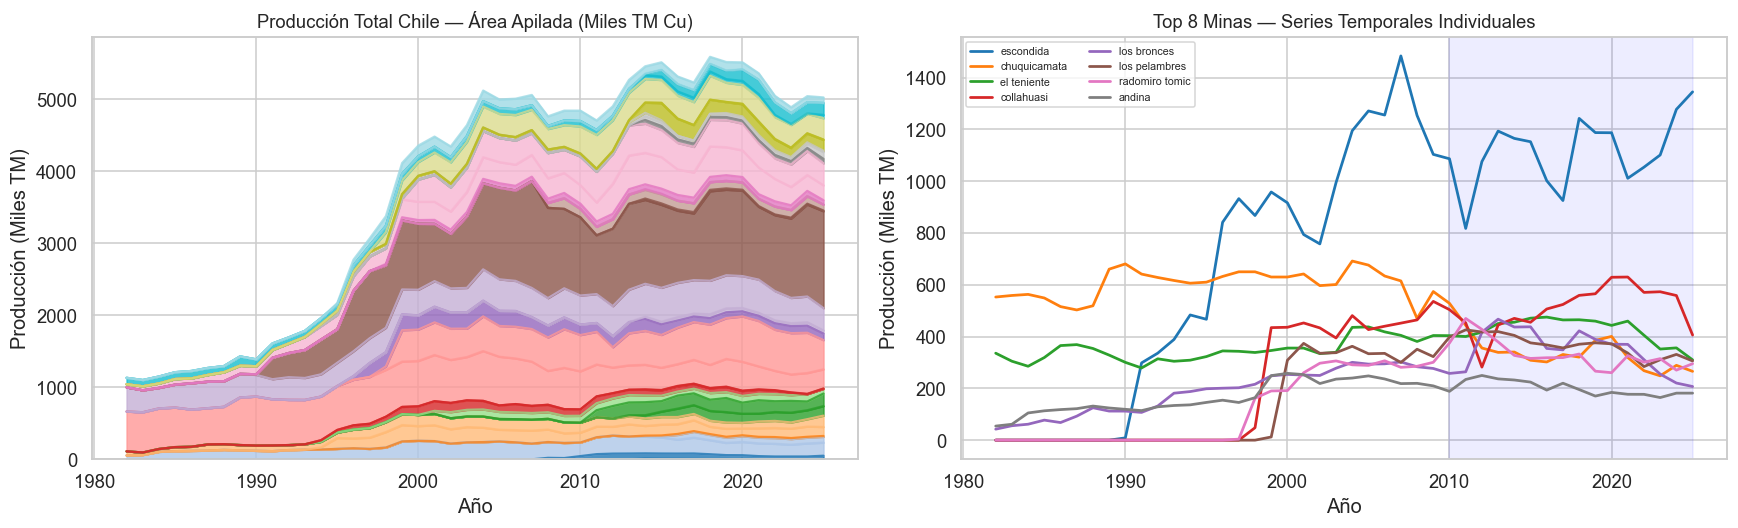

In [4]:
# ── Serie temporal de producción (todas las minas) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Área apilada — producción total de Chile
pivot = df_raw.pivot_table(index='Anio', columns='Match_Key', values='Produccion', aggfunc='sum').fillna(0)
pivot.plot(kind='area', stacked=True, ax=axes[0], legend=False, colormap='tab20', alpha=0.8)
axes[0].set_title('Producción Total Chile — Área Apilada (Miles TM Cu)', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Producción (Miles TM)')

# Líneas individuales — top 8 minas por promedio
top_mines = df_raw.groupby('Match_Key')['Produccion'].mean().nlargest(8).index
for mine in top_mines:
    sub = df_raw[df_raw['Match_Key'] == mine]
    axes[1].plot(sub['Anio'], sub['Produccion'], label=mine, linewidth=1.8)
axes[1].set_title('Top 8 Minas — Series Temporales Individuales', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Producción (Miles TM)')
axes[1].legend(fontsize=7, ncol=2)
# Marcar ventana de validación
axes[1].axvspan(2010, 2025, alpha=0.07, color='blue', label='Ventana validación')

plt.tight_layout()
plt.show()

## Sección 2 — Ingeniería de Features

Para cada par *(mine, origin_year)* se calculan las mismas features que usa el modelo final v8c, pero sin segmentación. Esto garantiza que la comparación sea justa.

| Feature | Descripción |
|---|---|
| `Prod_Lag1` | Producción en el año origen |
| `Mine_age` | Años desde inicio de producción (cap 36) |
| `Tendencia_5y` | Pendiente OLS sobre los últimos 5 años antes del origen |
| `Prod_pct_change` | Cambio pct año anterior al origen (clip ±2) |
| `Cu_regime` | Percentil del precio del cobre en ventana 10 años |
| `Mine_share` | Participación de la mina en prod. total Chile al origen |
| `Company_Size` | 0=Junior, 1=Large Indep., 2=State/Global Major |
| `Mine_Size` | Cuartil rolling 6 años (0=Small, 3=Colossal) |
| `Is_Pandemic_Target` | 1 si el año objetivo es 2020 o 2021 |
| `Capital_Stock_Lag1` | Capital acumulado en el año origen |

In [5]:
def ols_slope(years, values):
    """Pendiente OLS simple para una serie corta. Devuelve 0 si no hay datos suficientes."""
    x = np.array(years, dtype=float)
    y = np.array(values, dtype=float)
    mask = np.isfinite(y) & (y > 0)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        return 0.0
    x_c = x - x.mean()
    denom = np.dot(x_c, x_c)
    return float(np.dot(x_c, y) / denom) if denom != 0 else 0.0


def compute_mine_size_map(df, origin_year):
    """
    Mine_Size: cuartil (0-3) de la producción media en los 6 años previos al origen.
    Sigue el diseño del modelo final (rolling 6y, percentiles sobre el conjunto de minas).
    """
    avgs = {}
    for mine in MINES:
        sub = df[(df['Match_Key'] == mine) &
                 (df['Anio'] >= origin_year - 6) &
                 (df['Anio'] < origin_year)]['Produccion']
        avgs[mine] = float(sub.mean()) if (len(sub) > 0 and sub.sum() > 0) else 0.0
    vals = np.array(list(avgs.values()), dtype=float)
    q25, q50, q75 = np.percentile(vals, 25), np.percentile(vals, 50), np.percentile(vals, 75)
    return {
        m: (0 if v <= q25 else (1 if v <= q50 else (2 if v <= q75 else 3)))
        for m, v in avgs.items()
    }


def build_feature_dataframe(df_raw):
    """
    Construye df_features: una fila por (mine, origin, horizon) con todas las features
    y el LogRatio actual para comparar con predicciones.
    """
    # Precio del cobre: percentil rolling 10 años
    copper_prices = df_raw.groupby('Anio')['Precio_Cobre'].first().sort_index()
    copper_series = copper_prices.values
    copper_years  = copper_prices.index.values

    def cu_regime(year, window=10):
        mask = (copper_years >= year - window) & (copper_years <= year)
        hist = copper_series[mask]
        if len(hist) < 2:
            return 0.5
        cur = copper_prices.get(year, np.nan)
        if np.isnan(cur):
            return 0.5
        return float(np.mean(hist <= cur))

    records = []
    for origin_year in ORIGINS:
        mine_size_map = compute_mine_size_map(df_raw, origin_year)

        # Producción total Chile en el origen (para Mine_share)
        total_prod_origin = df_raw[df_raw['Anio'] == origin_year]['Produccion'].sum()

        for mine in MINES:
            mine_data = df_raw[df_raw['Match_Key'] == mine].sort_values('Anio')

            # ── Producción en el origen ──────────────────────────────────────
            prod_origin_row = mine_data[mine_data['Anio'] == origin_year]
            if len(prod_origin_row) == 0:
                continue
            prod_origin = float(prod_origin_row['Produccion'].values[0])
            if prod_origin <= 0:
                continue  # No hay producción en el origen → skip

            # ── Producción año anterior al origen (para pct_change) ──────────
            prev_row = mine_data[mine_data['Anio'] == origin_year - 1]
            prod_prev = float(prev_row['Produccion'].values[0]) if len(prev_row) > 0 else np.nan

            # ── Capital_Stock al origen ──────────────────────────────────────
            cap_stock = float(prod_origin_row['Capital_Stock'].values[0])

            # ── Tendencia 5 años ─────────────────────────────────────────────
            hist5 = mine_data[(mine_data['Anio'] >= origin_year - 5) &
                              (mine_data['Anio'] <= origin_year)]
            trend5 = ols_slope(hist5['Anio'].values, hist5['Produccion'].values)

            # ── Prod pct change ──────────────────────────────────────────────
            if pd.notna(prod_prev) and prod_prev > 0:
                pct_chg = (prod_origin - prod_prev) / prod_prev
            else:
                pct_chg = 0.0
            pct_chg = float(np.clip(pct_chg, -2.0, 2.0))

            # ── Mine age (capped at 36) ──────────────────────────────────────
            first_year = FIRST_PROD_YEAR.get(mine, START_YEAR_MAP.get(mine, origin_year))
            mine_age = min(origin_year - first_year, 36)
            mine_age = max(mine_age, 0)

            # ── Cu_regime ────────────────────────────────────────────────────
            cu_reg = cu_regime(origin_year)

            # ── Mine share ───────────────────────────────────────────────────
            mine_share = prod_origin / total_prod_origin if total_prod_origin > 0 else 0.0

            # ── Company_Size ─────────────────────────────────────────────────
            company_sz = COMPANY_SIZE.get(mine, 1)  # default 1 si no está mapeado

            # ── Mine_Size ────────────────────────────────────────────────────
            mine_sz = mine_size_map.get(mine, 1)

            # ── Un registro por horizonte ────────────────────────────────────
            for h in HORIZONS:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue

                # Producción real en el año objetivo
                target_row = mine_data[mine_data['Anio'] == target_year]
                if len(target_row) == 0:
                    continue
                prod_actual = float(target_row['Produccion'].values[0])
                if prod_actual <= 0:
                    continue

                # LogRatio actual = log(prod_target / prod_origin)
                log_ratio_actual = float(np.log(prod_actual / prod_origin))

                records.append({
                    'mine':              mine,
                    'origin':            origin_year,
                    'horizon':           h,
                    'target_year':       target_year,
                    'Prod_origin':       prod_origin,
                    'Prod_actual':       prod_actual,
                    'LogRatio_actual':   log_ratio_actual,
                    # Features
                    'Company_Size':      company_sz,
                    'Mine_Size':         mine_sz,
                    'Prod_Lag1':         prod_origin,
                    'Tendencia_5y':      trend5,
                    'Prod_pct_change':   pct_chg,
                    'Mine_age':          mine_age,
                    'Cu_regime':         cu_reg,
                    'Mine_share':        mine_share,
                    'Is_Pandemic_Target':1 if target_year in PANDEMIC_YEARS else 0,
                    'Capital_Stock_Lag1':cap_stock,
                    'Horizonte_feat':    h,
                })

    return pd.DataFrame(records)


print('Construyendo df_features...')
df_features = build_feature_dataframe(df_raw)
print(f'df_features: {len(df_features):,} filas × {len(df_features.columns)} columnas')
display(df_features.head(8))

Construyendo df_features...


df_features: 1,635 filas × 18 columnas


,mine,origin,horizon,target_year,Prod_origin,Prod_actual,LogRatio_actual,Company_Size,Mine_Size,Prod_Lag1,Tendencia_5y,Prod_pct_change,Mine_age,Cu_regime,Mine_share,Is_Pandemic_Target,Capital_Stock_Lag1,Horizonte_feat
0,andacollo,2010,1,2011,45.102,72.317,0.472133,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,1
1,andacollo,2010,2,2012,45.102,79.800,0.570597,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,2
2,andacollo,2010,3,2013,45.102,81.100,0.586756,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,3
3,andacollo,2010,4,2014,45.102,71.800,0.464958,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,4
4,andacollo,2010,5,2015,45.102,73.000,0.481533,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,5
5,andacollo,2010,6,2016,45.102,73.200,0.484269,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,6
6,andacollo,2010,7,2017,45.102,76.000,0.521807,1,1,45.102,12.020500,1.517415,2,1.0,0.009312,0,419.395565,7
7,andina,2010,1,2011,188.500,234.400,0.217931,2,3,188.500,-10.785714,-0.101097,28,1.0,0.038918,0,1665.163710,1


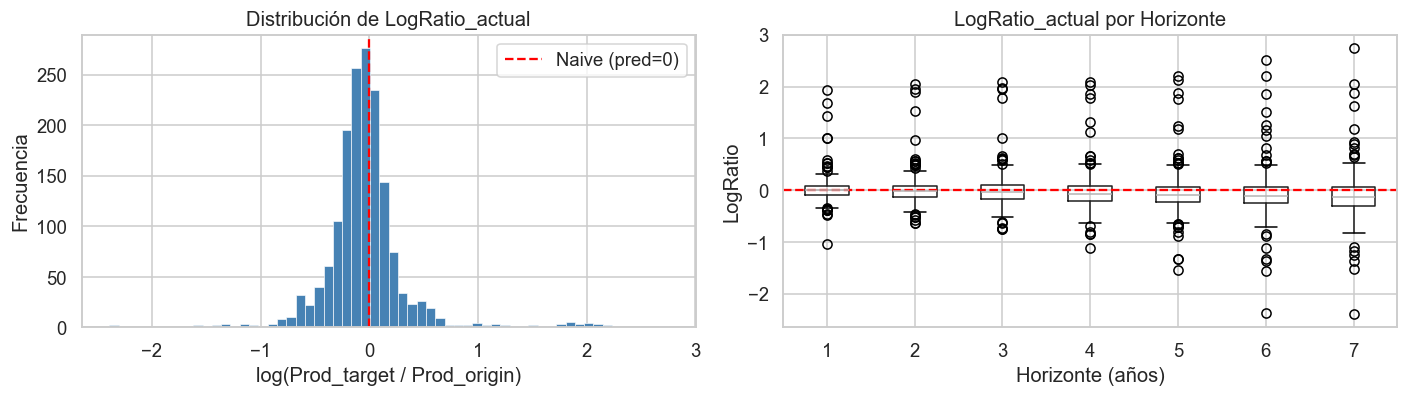


Estadísticas LogRatio_actual por horizonte:


,count,mean,std,min,25%,50%,75%,max
horizon,,,,,,,,
1,239.0,0.019,0.274,-1.045,-0.096,-0.004,0.072,1.935
2,235.0,0.009,0.323,-0.639,-0.131,-0.025,0.084,2.044
3,233.0,-0.006,0.353,-0.757,-0.176,-0.043,0.094,2.080
4,233.0,-0.031,0.388,-1.107,-0.215,-0.066,0.076,2.082
5,233.0,-0.059,0.421,-1.543,-0.220,-0.099,0.065,2.195
6,231.0,-0.085,0.469,-2.372,-0.256,-0.104,0.057,2.509
7,231.0,-0.102,0.488,-2.391,-0.299,-0.130,0.069,2.748


In [6]:
# ── Verificación de la distribución del target ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_features['LogRatio_actual'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Naive (pred=0)')
axes[0].set_title('Distribución de LogRatio_actual')
axes[0].set_xlabel('log(Prod_target / Prod_origin)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# LogRatio por horizonte (boxplot)
df_features.boxplot(column='LogRatio_actual', by='horizon', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('LogRatio_actual por Horizonte')
axes[1].set_xlabel('Horizonte (años)')
axes[1].set_ylabel('LogRatio')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nEstadísticas LogRatio_actual por horizonte:')
display(df_features.groupby('horizon')['LogRatio_actual'].describe().round(3))

In [7]:
# ── Lista de features ML ──────────────────────────────────────────────────────
ML_FEATURES = [
    'Company_Size', 'Mine_Size', 'Prod_Lag1', 'Tendencia_5y',
    'Prod_pct_change', 'Mine_age', 'Cu_regime', 'Mine_share',
    'Is_Pandemic_Target', 'Capital_Stock_Lag1', 'Horizonte_feat'
]

print('Features ML a usar:')
for i, f in enumerate(ML_FEATURES, 1):
    print(f'  {i:2d}. {f}')
print(f'\nTotal: {len(ML_FEATURES)} features')

Features ML a usar:
   1. Company_Size
   2. Mine_Size
   3. Prod_Lag1
   4. Tendencia_5y
   5. Prod_pct_change
   6. Mine_age
   7. Cu_regime
   8. Mine_share
   9. Is_Pandemic_Target
  10. Capital_Stock_Lag1
  11. Horizonte_feat

Total: 11 features


## Sección 3 — Marco de Validación Rolling-Origin

### Esquema de validación (texto)

```
Origen 2010 | Entrenamiento: Anio ≤ 2010 | Predicciones: 2011, 2012, ..., 2017  (H+1..H+7)
Origen 2011 | Entrenamiento: Anio ≤ 2011 | Predicciones: 2012, 2013, ..., 2018
Origen 2012 | Entrenamiento: Anio ≤ 2012 | Predicciones: 2013, 2014, ..., 2019
Origen 2013 | Entrenamiento: Anio ≤ 2013 | Predicciones: 2014, 2015, ..., 2020 *
Origen 2014 | Entrenamiento: Anio ≤ 2014 | Predicciones: 2015, 2016, ..., 2021 *
Origen 2015 | Entrenamiento: Anio ≤ 2015 | Predicciones: 2016, 2017, ..., 2022
Origen 2016 | Entrenamiento: Anio ≤ 2016 | Predicciones: 2017, 2018, ..., 2023
Origen 2017 | Entrenamiento: Anio ≤ 2017 | Predicciones: 2018, 2019, ..., 2024
Origen 2018 | Entrenamiento: Anio ≤ 2018 | Predicciones: 2019, 2020, ..., 2025
```
(*) El año objetivo incluye años con pandemia COVID-19, capturado por la feature `Is_Pandemic_Target`.

**Restricción de no-leakage:** El conjunto de entrenamiento de cada origen sólo contiene datos con `Anio ≤ origin_year`. Los hiperparámetros de los modelos son fijos (sin Optuna), lo que es la principal diferencia con el modelo final v8c.

### Métricas de evaluación

- **Win Rate (WR):** porcentaje de predicciones donde el error absoluto del modelo es menor al error absoluto del naive (que siempre predice LogRatio = 0). WR > 50% → el modelo supera al naive.
- **MASE:** error del modelo / error del naive en unidades de producción. MASE < 1 → mejor que naive.
- **Skill Score:** 1 − MAE_modelo / MAE_naive en el espacio LogRatio. Positivo → mejor que naive.

In [8]:
def compute_win_rate(pred_lr, actual_lr):
    """
    Win Rate: fracción de casos donde el modelo gana al naive.
    Naive siempre predice LogRatio = 0.

    Parameters
    ----------
    pred_lr   : array-like, predicciones en espacio LogRatio
    actual_lr : array-like, valores reales en espacio LogRatio

    Returns
    -------
    wr : float [0, 1]
    wins : bool array
    """
    pred_lr   = np.asarray(pred_lr,   dtype=float)
    actual_lr = np.asarray(actual_lr, dtype=float)
    err_model = np.abs(pred_lr - actual_lr)
    err_naive = np.abs(actual_lr)          # naive predice 0, error = |actual - 0|
    wins = err_model < err_naive
    return float(np.mean(wins)), wins


def compute_mase(pred_prod, actual_prod, naive_prod):
    """
    MASE en espacio de producción (Miles TM).
    MASE = MAE_modelo / MAE_naive
    """
    pred_prod   = np.asarray(pred_prod,   dtype=float)
    actual_prod = np.asarray(actual_prod, dtype=float)
    naive_prod  = np.asarray(naive_prod,  dtype=float)
    mae_model = np.mean(np.abs(pred_prod - actual_prod))
    mae_naive = np.mean(np.abs(naive_prod - actual_prod))
    return float(mae_model / mae_naive) if mae_naive > 0 else np.nan


def compute_skill(pred_lr, actual_lr, naive_lr=0.0):
    """
    Skill Score = 1 - MAE_modelo / MAE_naive en espacio LogRatio.
    Positivo → mejor que naive. Negativo → peor que naive.
    """
    pred_lr   = np.asarray(pred_lr,   dtype=float)
    actual_lr = np.asarray(actual_lr, dtype=float)
    mae_model = np.mean(np.abs(pred_lr - actual_lr))
    mae_naive = np.mean(np.abs(actual_lr - naive_lr))
    return float(1.0 - mae_model / mae_naive) if mae_naive > 0 else np.nan


def logratio_to_prod(pred_lr, prod_origin):
    """Convierte predicción de LogRatio a producción en Miles TM."""
    return np.asarray(prod_origin, dtype=float) * np.exp(np.asarray(pred_lr, dtype=float))


print('Funciones de métricas definidas:')
print('  compute_win_rate(pred_lr, actual_lr)')
print('  compute_mase(pred_prod, actual_prod, naive_prod)')
print('  compute_skill(pred_lr, actual_lr)')
print('  logratio_to_prod(pred_lr, prod_origin)')

# ── TrimMAPE 20–80% ──────────────────────────────────────────────────────
def trim_mape(pred_prod, actual_prod, trim=0.20):
    """Trimmed MAPE: remove bottom and top trim% of APE, return mean of middle 60%."""
    pred_prod   = np.asarray(pred_prod,   dtype=float)
    actual_prod = np.asarray(actual_prod, dtype=float)
    mask = actual_prod > 0
    ape  = np.abs(actual_prod[mask] - pred_prod[mask]) / actual_prod[mask] * 100
    if len(ape) < 5:
        return np.nan
    lo, hi = np.percentile(ape, trim * 100), np.percentile(ape, (1 - trim) * 100)
    trimmed = ape[(ape >= lo) & (ape <= hi)]
    return trimmed.mean() if len(trimmed) > 0 else np.nan

def trim_mape_skill(pred_prod, actual_prod, naive_prod, trim=0.20):
    """TrimMAPE Skill: positive = model beats naive."""
    tm_model = trim_mape(pred_prod, actual_prod, trim)
    tm_naive  = trim_mape(naive_prod, actual_prod, trim)
    if np.isnan(tm_model) or np.isnan(tm_naive) or tm_naive == 0:
        return np.nan
    return (tm_naive - tm_model) / tm_naive * 100

print('TrimMAPE 20–80% functions defined.')


Funciones de métricas definidas:
  compute_win_rate(pred_lr, actual_lr)
  compute_mase(pred_prod, actual_prod, naive_prod)
  compute_skill(pred_lr, actual_lr)
  logratio_to_prod(pred_lr, prod_origin)
TrimMAPE 20–80% functions defined.


In [9]:
def evaluate_model(pred_df, model_name='Model'):
    """
    Calcula todas las métricas para un modelo dado.

    Parameters
    ----------
    pred_df : DataFrame con columnas [mine, origin, horizon, pred_logratio]

    Returns
    -------
    dict con métricas: wr_overall, wr_by_horizon, mase, skill, wr_by_mine, wr_by_origin
    """
    # Merge con df_features para obtener actual y prod_origin
    merged = pred_df.merge(
        df_features[['mine', 'origin', 'horizon', 'LogRatio_actual', 'Prod_actual', 'Prod_origin']],
        on=['mine', 'origin', 'horizon'], how='inner'
    )
    if len(merged) == 0:
        print(f'ADVERTENCIA: No hay datos para evaluar {model_name}')
        return {}

    # Win Rate global
    wr_global, _ = compute_win_rate(merged['pred_logratio'], merged['LogRatio_actual'])

    # Win Rate por horizonte
    wr_by_h = {}
    for h in HORIZONS:
        sub = merged[merged['horizon'] == h]
        if len(sub) > 0:
            wr_h, _ = compute_win_rate(sub['pred_logratio'], sub['LogRatio_actual'])
            wr_by_h[h] = wr_h

    # MASE en espacio producción
    pred_prod  = logratio_to_prod(merged['pred_logratio'], merged['Prod_origin'])
    naive_prod = merged['Prod_origin'].values  # naive = sin cambio
    mase = compute_mase(pred_prod, merged['Prod_actual'].values, naive_prod)

    # Skill Score
    skill = compute_skill(merged['pred_logratio'], merged['LogRatio_actual'])

    # Win Rate por mina
    wr_by_mine = {}
    for mine in merged['mine'].unique():
        sub = merged[merged['mine'] == mine]
        wr_m, _ = compute_win_rate(sub['pred_logratio'], sub['LogRatio_actual'])
        wr_by_mine[mine] = wr_m

    # Win Rate por origen
    wr_by_origin = {}
    for orig in sorted(merged['origin'].unique()):
        sub = merged[merged['origin'] == orig]
        wr_o, _ = compute_win_rate(sub['pred_logratio'], sub['LogRatio_actual'])
        wr_by_origin[orig] = wr_o

    return {
        'model':        model_name,
        'wr_overall':   wr_global,
        'wr_by_horizon':wr_by_h,
        'mase':         mase,
        'skill':        skill,
        'wr_by_mine':   wr_by_mine,
        'wr_by_origin': wr_by_origin,
        'n_obs':        len(merged),
    }


print('evaluate_model() definida.')

evaluate_model() definida.


## Sección 4 — Baselines Estadísticos

Modelos sin features de ML. Usan sólo la historia de producción de cada mina hasta el año origen.

### 4.1 Naive

La referencia canónica: predice que la producción no cambia (LogRatio = 0). Por construcción, el Win Rate del Naive es exactamente 50% cuando las predicciones del modelo no son exactamente iguales al actual (se considera empate como derrota del modelo). En la práctica, el WR del Naive es el umbral de 50%.

In [10]:
# ── Naive: pred_logratio = 0 para todos ──────────────────────────────────────
naive_records = df_features[['mine', 'origin', 'horizon']].copy()
naive_records['pred_logratio'] = 0.0

# El WR del naive contra sí mismo es 50% por definición
# (en la práctica, ninguna predicción gana al naive cuando pred = actual ± epsilon)
# Lo incluimos como referencia
all_preds = {}
all_preds['Naive'] = naive_records.copy()

metrics_naive = evaluate_model(naive_records, 'Naive')
print(f"Naive — WR global: {metrics_naive['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_naive['mase']:.3f} | "
      f"Skill: {metrics_naive['skill']*100:.1f}%")
print('(El WR del naive contra sí mismo es 0% porque nunca gana por definición.')
print(' En las tablas se mostrará como 50% de referencia.)')

Naive — WR global: 0.0% | MASE: 1.000 | Skill: 0.0%
(El WR del naive contra sí mismo es 0% porque nunca gana por definición.
 En las tablas se mostrará como 50% de referencia.)


### 4.2 HistMean_5y

Predice que la producción futura será igual a la media de los últimos 5 años antes del origen.

In [11]:
def predict_hist_mean(df_raw, origins, horizons, window=5):
    """
    Para cada (mine, origin), la predicción es la media de los últimos `window` años.
    Constante para todos los horizontes.
    """
    records = []
    for origin_year in origins:
        for mine in MINES:
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] >= origin_year - window) &
                (df_raw['Anio'] <= origin_year)
            ]['Produccion'].values
            hist = hist[hist > 0]

            # Producción en el origen
            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) == 0:
                continue

            pred_prod = float(np.mean(hist))
            pred_lr   = np.log(pred_prod / prod_origin)

            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': pred_lr
                })
    return pd.DataFrame(records)


print('Calculando HistMean_5y...')
hm5_preds = predict_hist_mean(df_raw, ORIGINS, HORIZONS, window=5)
all_preds['HistMean_5y'] = hm5_preds
metrics_hm5 = evaluate_model(hm5_preds, 'HistMean_5y')
print(f"HistMean_5y — WR: {metrics_hm5['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_hm5['mase']:.3f} | Skill: {metrics_hm5['skill']*100:.1f}%")

Calculando HistMean_5y...


HistMean_5y — WR: 37.5% | MASE: 1.133 | Skill: -19.0%


### 4.3 LinTrend

Extrapolación lineal OLS sobre los últimos 5 años. La predicción para H+h es la extrapolación en `origin + h`.

In [12]:
def predict_lin_trend(df_raw, origins, horizons, window=5):
    """
    OLS sobre últimos `window` años, extrapolado a cada horizonte.
    Producción predicha capped en 1 Mile TM mínimo (evita log de negativo).
    """
    records = []
    for origin_year in origins:
        for mine in MINES:
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] >= origin_year - window) &
                (df_raw['Anio'] <= origin_year)
            ][['Anio', 'Produccion']].sort_values('Anio')
            hist = hist[hist['Produccion'] > 0]

            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) < 2:
                continue

            x = hist['Anio'].values.reshape(-1, 1)
            y = hist['Produccion'].values
            lr = LinearRegression().fit(x, y)

            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                pred_prod = float(lr.predict([[target_year]])[0])
                pred_prod = max(pred_prod, 1.0)  # evitar log de negativo
                pred_lr   = np.log(pred_prod / prod_origin)
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': pred_lr
                })
    return pd.DataFrame(records)


print('Calculando LinTrend...')
lt_preds = predict_lin_trend(df_raw, ORIGINS, HORIZONS, window=5)
all_preds['LinTrend'] = lt_preds
metrics_lt = evaluate_model(lt_preds, 'LinTrend')
print(f"LinTrend — WR: {metrics_lt['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_lt['mase']:.3f} | Skill: {metrics_lt['skill']*100:.1f}%")

Calculando LinTrend...


LinTrend — WR: 29.0% | MASE: 2.180 | Skill: -104.7%


### 4.4 ExpSmooth

Suavizado exponencial simple (SES) con ajuste automático del parámetro alpha.

In [13]:
def predict_exp_smooth(df_raw, origins, horizons):
    """
    ExponentialSmoothing(trend=None) — SES optimizado automáticamente.
    El pronóstico más allá de 1 paso es constante en el nivel estimado.
    """
    records = []
    for origin_year in origins:
        for mine in MINES:
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] <= origin_year)
            ]['Produccion'].values
            hist = hist[hist > 0]

            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) < 3:
                continue

            try:
                fit = ExponentialSmoothing(hist, trend=None).fit(optimized=True)
                forecasts = fit.forecast(max(HORIZONS))
            except Exception:
                # Fallback: media histórica
                forecasts = [float(np.mean(hist))] * max(HORIZONS)

            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                pred_prod = max(float(forecasts[h - 1]), 1.0)
                pred_lr   = np.log(pred_prod / prod_origin)
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': pred_lr
                })
    return pd.DataFrame(records)


print('Calculando ExpSmooth...')
es_preds = predict_exp_smooth(df_raw, ORIGINS, HORIZONS)
all_preds['ExpSmooth'] = es_preds
metrics_es = evaluate_model(es_preds, 'ExpSmooth')
print(f"ExpSmooth — WR: {metrics_es['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_es['mase']:.3f} | Skill: {metrics_es['skill']*100:.1f}%")

Calculando ExpSmooth...


ExpSmooth — WR: 50.0% | MASE: 1.022 | Skill: -0.6%


### 4.5 Holt (Suavizado Exponencial con Tendencia)

Holt lineal con parámetros fijos: alpha=0.3, beta=0.1.

In [14]:
def predict_holt(df_raw, origins, horizons):
    # Holt lineal (trend='add', damped_trend=True) con parametros optimizados.
    records = []
    for origin_year in origins:
        for mine in MINES:
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] <= origin_year)
            ]['Produccion'].values
            hist = hist[hist > 0]
            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) < 4:
                continue
            try:
                fit = ExponentialSmoothing(
                    hist, trend='add', damped_trend=True
                ).fit(optimized=True)
                forecasts = fit.forecast(max(horizons))
            except Exception:
                try:
                    fit = ExponentialSmoothing(hist, trend='add').fit(optimized=True)
                    forecasts = fit.forecast(max(horizons))
                except Exception:
                    forecasts = [prod_origin] * max(horizons)
            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                pred_prod = max(float(forecasts[h - 1]), 0.01)
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': np.log(pred_prod / prod_origin),
                })
    return pd.DataFrame(records)

holt_df = predict_holt(df_raw, ORIGINS, HORIZONS)
all_preds['Holt'] = holt_df
metrics_holt = evaluate_model(holt_df, 'Holt')
print(f"Holt (optimized+damped) — WR: {metrics_holt['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_holt['mase']:.3f} | Skill: {metrics_holt['skill']*100:.1f}%")


### 4.6 ARIMA(1,1,1)

ARIMA por mina y por origen. Si falla, se usa ARIMA(0,1,0) como fallback.

In [15]:
def predict_arima(df_raw, origins, horizons, order=(1, 1, 1)):
    """
    ARIMA(p,d,q) por mina y por origen.
    Fallback: ARIMA(0,1,0) si (1,1,1) falla.
    """
    records = []
    total = len(origins) * len(MINES)
    count = 0
    fallbacks = 0

    for origin_year in origins:
        for mine in MINES:
            count += 1
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] <= origin_year)
            ]['Produccion'].values
            hist = hist[hist > 0]

            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) < 4:
                continue

            # Intentar ARIMA(1,1,1)
            forecasts = None
            try:
                model = ARIMA(hist, order=order)
                fit   = model.fit()
                forecasts = fit.forecast(steps=max(horizons))
            except Exception:
                pass

            # Fallback ARIMA(0,1,0)
            if forecasts is None:
                fallbacks += 1
                try:
                    model = ARIMA(hist, order=(0, 1, 0))
                    fit   = model.fit()
                    forecasts = fit.forecast(steps=max(horizons))
                except Exception:
                    forecasts = [float(np.mean(hist))] * max(horizons)

            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                pred_prod = max(float(forecasts[h - 1]), 1.0)
                pred_lr   = np.log(pred_prod / prod_origin)
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': pred_lr
                })

    print(f'  Fallbacks a ARIMA(0,1,0): {fallbacks}/{total} ({fallbacks/total*100:.1f}%)')
    return pd.DataFrame(records)


print('Calculando ARIMA(1,1,1) — puede tardar ~1-2 minutos...')
arima_preds = predict_arima(df_raw, ORIGINS, HORIZONS, order=(1, 1, 1))
all_preds['ARIMA(1,1,1)'] = arima_preds
metrics_arima = evaluate_model(arima_preds, 'ARIMA(1,1,1)')
print(f"ARIMA(1,1,1) — WR: {metrics_arima['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_arima['mase']:.3f} | Skill: {metrics_arima['skill']*100:.1f}%")

Calculando ARIMA(1,1,1) — puede tardar ~1-2 minutos...


  Fallbacks a ARIMA(0,1,0): 0/306 (0.0%)
ARIMA(1,1,1) — WR: 47.1% | MASE: 1.145 | Skill: -22.9%


In [ ]:
# ── 4.7 Auto-ARIMA anual (per mine/origin, AIC-selected) ────────────────────
def predict_auto_arima_annual(df_raw, origins, horizons):
    records = []
    for origin_year in origins:
        for mine in MINES:
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] <= origin_year)
            ]['Produccion'].values
            hist = hist[hist > 0]
            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) < 5:
                continue
            try:
                model = auto_arima(
                    hist, d=1, max_p=3, max_q=3,
                    seasonal=False,
                    information_criterion='aic',
                    stepwise=True,
                    suppress_warnings=True,
                    error_action='ignore',
                )
                fc = model.predict(max(horizons))
            except Exception:
                fc = [prod_origin] * max(horizons)
            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                pred_prod = max(float(fc[h - 1]), 0.01)
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': np.log(pred_prod / prod_origin),
                })
    return pd.DataFrame(records)

auto_arima_annual_df = predict_auto_arima_annual(df_raw, ORIGINS, HORIZONS)
all_preds['AutoARIMA'] = auto_arima_annual_df
metrics_aa = evaluate_model(auto_arima_annual_df, 'AutoARIMA')
print(f"Auto-ARIMA — WR: {metrics_aa['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_aa['mase']:.3f} | Skill: {metrics_aa['skill']*100:.1f}%")


In [ ]:
# ── 4.8 Holt-Winters anual (damped trend, optimized) ────────────────────────
def predict_hw_annual(df_raw, origins, horizons):
    records = []
    for origin_year in origins:
        for mine in MINES:
            hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'] <= origin_year)
            ]['Produccion'].values
            hist = hist[hist > 0]
            prod_orig_row = df_raw[(df_raw['Match_Key'] == mine) &
                                   (df_raw['Anio'] == origin_year)]
            if len(prod_orig_row) == 0:
                continue
            prod_origin = float(prod_orig_row['Produccion'].values[0])
            if prod_origin <= 0 or len(hist) < 4:
                continue
            try:
                fit = ExponentialSmoothing(
                    hist, trend='add', damped_trend=True
                ).fit(optimized=True)
                forecasts = fit.forecast(max(horizons))
            except Exception:
                forecasts = [prod_origin] * max(horizons)
            for h in horizons:
                target_year = origin_year + h
                if target_year > BASE_YEAR:
                    continue
                pred_prod = max(float(forecasts[h - 1]), 0.01)
                records.append({
                    'mine': mine, 'origin': origin_year,
                    'horizon': h, 'pred_logratio': np.log(pred_prod / prod_origin),
                })
    return pd.DataFrame(records)

hw_annual_df = predict_hw_annual(df_raw, ORIGINS, HORIZONS)
all_preds['HoltWinters'] = hw_annual_df
metrics_hw = evaluate_model(hw_annual_df, 'HoltWinters')
print(f"Holt-Winters — WR: {metrics_hw['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_hw['mase']:.3f} | Skill: {metrics_hw['skill']*100:.1f}%")


## Sección 5 — Baselines de Machine Learning

Los modelos ML usan todas las features de `df_features`. Para cada origen, el entrenamiento usa datos con `target_year ≤ origin_year` (sin leakage). El horizonte `h` se incluye como feature numérica (`Horizonte_feat`), permitiendo entrenar todos los horizontes juntos (multi-horizon).

**Sin Optuna:** los hiperparámetros son fijos (por defecto o levemente ajustados). Esta es la principal diferencia con el modelo final v8c.

In [16]:
def run_ml_baseline(model_cls, model_kwargs, model_name, scale_features=False):
    """
    Marco general de validación rolling-origin para modelos ML.

    Para cada origin_year:
      - Entrenamiento: filas donde target_year <= origin_year
      - Predicción: filas donde origin == origin_year

    Devuelve un DataFrame con columnas [mine, origin, horizon, pred_logratio].
    """
    records = []

    for origin_year in ORIGINS:
        # ── Datos de entrenamiento ───────────────────────────────────────────
        # target_year = origin + horizon; para no tener leakage:
        # usamos todas las filas donde origin + horizon <= current_origin
        # equivalente a: origin <= current_origin AND target_year <= current_origin
        train_mask = (df_features['target_year'] <= origin_year)
        df_train   = df_features[train_mask].dropna(subset=ML_FEATURES + ['LogRatio_actual'])

        if len(df_train) < 20:
            # No hay suficientes datos para entrenar
            continue

        X_train = df_train[ML_FEATURES].values
        y_train = df_train['LogRatio_actual'].values

        # ── Estandarización (sólo si el modelo lo requiere) ──────────────────
        scaler = None
        if scale_features:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)

        # ── Entrenar modelo ──────────────────────────────────────────────────
        model = model_cls(**model_kwargs)
        model.fit(X_train, y_train)

        # ── Predicciones para este origen ────────────────────────────────────
        pred_mask = (df_features['origin'] == origin_year)
        df_pred   = df_features[pred_mask].dropna(subset=ML_FEATURES)

        if len(df_pred) == 0:
            continue

        X_pred = df_pred[ML_FEATURES].values
        if scale_features and scaler is not None:
            X_pred = scaler.transform(X_pred)

        preds = model.predict(X_pred)

        for i, (_, row) in enumerate(df_pred.iterrows()):
            records.append({
                'mine':         row['mine'],
                'origin':       row['origin'],
                'horizon':      row['horizon'],
                'pred_logratio': float(preds[i]),
            })

    result_df = pd.DataFrame(records)
    return result_df


print('run_ml_baseline() definida.')
print(f'Features: {ML_FEATURES}')

run_ml_baseline() definida.
Features: ['Company_Size', 'Mine_Size', 'Prod_Lag1', 'Tendencia_5y', 'Prod_pct_change', 'Mine_age', 'Cu_regime', 'Mine_share', 'Is_Pandemic_Target', 'Capital_Stock_Lag1', 'Horizonte_feat']


In [ ]:
# ── 5.0 Enhanced features: Prod_vs_peak ─────────────────────────────────────
# Prod_vs_peak = production at origin / historical peak for that mine
prod_vs_peak_map = {}
for mine in MINES:
    mine_data = df_raw[df_raw['Match_Key'] == mine].sort_values('Anio')
    for origin_year in ORIGINS:
        hist_prod = mine_data[mine_data['Anio'] <= origin_year]['Produccion']
        hist_prod = hist_prod[hist_prod > 0]
        if len(hist_prod) == 0:
            prod_vs_peak_map[(mine, origin_year)] = 1.0
            continue
        current_rows = mine_data[mine_data['Anio'] == origin_year]['Produccion']
        current = float(current_rows.values[0]) if len(current_rows) > 0 else float(hist_prod.iloc[-1])
        peak = float(hist_prod.max())
        prod_vs_peak_map[(mine, origin_year)] = current / peak if peak > 0 else 1.0

df_features['Prod_vs_peak'] = df_features.apply(
    lambda r: prod_vs_peak_map.get((r['mine'], r['origin']), 1.0), axis=1
)

ML_FEATURES_ENHANCED = ML_FEATURES + ['Prod_vs_peak']
print(f'Enhanced feature set: {len(ML_FEATURES_ENHANCED)} features')
print(f'  Added: Prod_vs_peak')


In [ ]:
# ── 5.0b run_ml_baseline_segmented (annual) ──────────────────────────────────
def run_ml_baseline_segmented_annual(model_cls_sm, kwargs_sm,
                                     model_cls_lc, kwargs_lc,
                                     model_name, feat_cols=None):
    if feat_cols is None:
        feat_cols = ML_FEATURES_ENHANCED
    records = []
    for origin_year in ORIGINS:
        train_mask = df_features['target_year'] <= origin_year
        origin_mask = df_features['origin'] == origin_year
        for seg_label, seg_fn, m_cls, m_kw in [
            ('SM', lambda d: d['Mine_Size'] <= 1, model_cls_sm, kwargs_sm),
            ('LC', lambda d: d['Mine_Size'] >= 2, model_cls_lc, kwargs_lc),
        ]:
            df_tr = df_features[train_mask & seg_fn(df_features)].dropna(
                subset=feat_cols + ['LogRatio_actual'])
            df_te = df_features[origin_mask & seg_fn(df_features)].dropna(subset=feat_cols)
            if len(df_tr) < 10 or len(df_te) == 0:
                continue
            model = m_cls(**m_kw)
            try:
                model.fit(df_tr[feat_cols].values, df_tr['LogRatio_actual'].values)
                pred_vals = model.predict(df_te[feat_cols].values)
                for row_idx, (_, row) in enumerate(df_te.iterrows()):
                    records.append({
                        'mine': row['mine'], 'origin': row['origin'],
                        'horizon': row['horizon'],
                        'pred_logratio': float(pred_vals[row_idx]),
                    })
            except Exception:
                pass
    result_df = pd.DataFrame(records)
    m = evaluate_model(result_df, model_name)
    print(f"{model_name} — WR: {m['wr_overall']*100:.1f}% | "
          f"MASE: {m['mase']:.3f} | Skill: {m['skill']*100:.1f}%")
    return result_df

print('run_ml_baseline_segmented_annual defined.')


### 5.1 Regresión Lineal

In [17]:
print('Entrenando LinearRegression...')
lr_preds = run_ml_baseline(
    LinearRegression, {}, 'LinearReg', scale_features=True
)
all_preds['LinearReg'] = lr_preds
metrics_lr = evaluate_model(lr_preds, 'LinearReg')
print(f"LinearReg — WR: {metrics_lr['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_lr['mase']:.3f} | Skill: {metrics_lr['skill']*100:.1f}%")

Entrenando LinearRegression...
LinearReg — WR: 38.0% | MASE: 1.200 | Skill: -11.7%


### 5.2 Ridge (alpha=1.0)

In [18]:
print('Entrenando Ridge(alpha=1.0)...')
ridge_preds = run_ml_baseline(
    Ridge, {'alpha': 1.0}, 'Ridge', scale_features=True
)
all_preds['Ridge'] = ridge_preds
metrics_ridge = evaluate_model(ridge_preds, 'Ridge')
print(f"Ridge — WR: {metrics_ridge['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_ridge['mase']:.3f} | Skill: {metrics_ridge['skill']*100:.1f}%")

Entrenando Ridge(alpha=1.0)...
Ridge — WR: 37.4% | MASE: 1.177 | Skill: -11.3%


### 5.3 Random Forest

In [19]:
print('Entrenando RandomForest...')
rf_preds = run_ml_baseline(
    RandomForestRegressor,
    {'n_estimators': 100, 'max_depth': 6, 'random_state': RANDOM_SEED, 'n_jobs': -1},
    'RandomForest',
    scale_features=False  # RF no requiere estandarización
)
all_preds['RandomForest'] = rf_preds
metrics_rf = evaluate_model(rf_preds, 'RandomForest')
print(f"RandomForest — WR: {metrics_rf['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_rf['mase']:.3f} | Skill: {metrics_rf['skill']*100:.1f}%")

Entrenando RandomForest...


RandomForest — WR: 46.5% | MASE: 1.115 | Skill: -12.7%


### 5.4 LightGBM

In [20]:
print('Entrenando LightGBM...')
lgbm_preds = run_ml_baseline(
    lgb.LGBMRegressor,
    {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'max_depth': 5,
        'num_leaves': 31,
        'random_state': RANDOM_SEED,
        'verbose': -1,
        'n_jobs': -1,
    },
    'LightGBM',
    scale_features=False
)
all_preds['LightGBM'] = lgbm_preds
metrics_lgbm = evaluate_model(lgbm_preds, 'LightGBM')
print(f"LightGBM — WR: {metrics_lgbm['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_lgbm['mase']:.3f} | Skill: {metrics_lgbm['skill']*100:.1f}%")

Entrenando LightGBM...


LightGBM — WR: 44.8% | MASE: 1.094 | Skill: -10.6%


### 5.5 XGBoost

In [21]:
print('Entrenando XGBoost...')
xgb_preds = run_ml_baseline(
    xgb.XGBRegressor,
    {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'max_depth': 4,
        'random_state': RANDOM_SEED,
        'verbosity': 0,
        'n_jobs': -1,
    },
    'XGBoost',
    scale_features=False
)
all_preds['XGBoost'] = xgb_preds
metrics_xgb = evaluate_model(xgb_preds, 'XGBoost')
print(f"XGBoost — WR: {metrics_xgb['wr_overall']*100:.1f}% | "
      f"MASE: {metrics_xgb['mase']:.3f} | Skill: {metrics_xgb['skill']*100:.1f}%")

Entrenando XGBoost...


XGBoost — WR: 47.6% | MASE: 1.229 | Skill: -19.9%


In [ ]:
# ── 5.6 Random Forest — Segmented + Enhanced features ───────────────────────
rf_seg_df = run_ml_baseline_segmented_annual(
    RandomForestRegressor, {'n_estimators': 200, 'max_depth': 6,
                             'min_samples_leaf': 2, 'random_state': RANDOM_SEED, 'n_jobs': -1},
    RandomForestRegressor, {'n_estimators': 200, 'max_depth': 6,
                             'min_samples_leaf': 2, 'random_state': RANDOM_SEED, 'n_jobs': -1},
    'RF_Seg'
)
all_preds['RF_Seg'] = rf_seg_df


In [ ]:
# ── 5.7 LightGBM — Segmented + Enhanced features ────────────────────────────
lgb_seg_df = run_ml_baseline_segmented_annual(
    lgb.LGBMRegressor, {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5,
                         'num_leaves': 31, 'random_state': RANDOM_SEED,
                         'verbose': -1, 'n_jobs': -1},
    lgb.LGBMRegressor, {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5,
                         'num_leaves': 31, 'random_state': RANDOM_SEED,
                         'verbose': -1, 'n_jobs': -1},
    'LGB_Seg'
)
all_preds['LGB_Seg'] = lgb_seg_df


In [ ]:
# ── 5.8 XGBoost — Segmented + Enhanced features ─────────────────────────────
xgb_seg_df = run_ml_baseline_segmented_annual(
    xgb.XGBRegressor, {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4,
                        'random_state': RANDOM_SEED, 'verbosity': 0, 'n_jobs': -1},
    xgb.XGBRegressor, {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4,
                        'random_state': RANDOM_SEED, 'verbosity': 0, 'n_jobs': -1},
    'XGB_Seg'
)
all_preds['XGB_Seg'] = xgb_seg_df


In [ ]:
# ── 5.9 LightGBM — Segmented + Optuna hyperparameter tuning ────────────────
def optuna_lgb_annual(feat_cols=None, n_trials=40):
    if feat_cols is None:
        feat_cols = ML_FEATURES_ENHANCED
    records = []
    best_params = {}

    for origin_year in ORIGINS:
        train_mask  = df_features['target_year'] <= origin_year
        origin_mask = df_features['origin'] == origin_year

        for seg_label, seg_fn in [('SM', lambda d: d['Mine_Size'] <= 1),
                                   ('LC', lambda d: d['Mine_Size'] >= 2)]:
            tr_all = df_features[train_mask & seg_fn(df_features)].dropna(
                subset=feat_cols + ['LogRatio_actual'])
            te = df_features[origin_mask & seg_fn(df_features)].dropna(subset=feat_cols)
            if len(tr_all) < 15 or len(te) == 0:
                continue

            cv_origins = sorted(tr_all['origin'].unique())
            if seg_label not in best_params and len(cv_origins) >= 3:
                def objective(trial):
                    p = dict(
                        n_estimators=trial.suggest_int('n_estimators', 50, 400),
                        learning_rate=trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                        max_depth=trial.suggest_int('max_depth', 3, 8),
                        num_leaves=trial.suggest_int('num_leaves', 15, 63),
                        min_child_samples=trial.suggest_int('min_child_samples', 3, 30),
                        reg_alpha=trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
                        reg_lambda=trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
                        random_state=RANDOM_SEED, verbose=-1,
                    )
                    errs = []
                    for vo in cv_origins[-3:]:
                        cv_tr = tr_all[tr_all['origin'] < vo]
                        cv_va = tr_all[tr_all['origin'] == vo]
                        if len(cv_tr) < 10 or len(cv_va) == 0:
                            continue
                        m = lgb.LGBMRegressor(**p)
                        m.fit(cv_tr[feat_cols].values, cv_tr['LogRatio_actual'].values)
                        errs.append(mean_absolute_error(
                            cv_va['LogRatio_actual'].values,
                            m.predict(cv_va[feat_cols].values)
                        ))
                    return float(np.mean(errs)) if errs else float('inf')

                study = optuna.create_study(direction='minimize')
                study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
                best_params[seg_label] = {**study.best_params,
                                           'random_state': RANDOM_SEED, 'verbose': -1}

            params = best_params.get(seg_label, {
                'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5,
                'num_leaves': 31, 'random_state': RANDOM_SEED, 'verbose': -1
            })
            m = lgb.LGBMRegressor(**params)
            try:
                m.fit(tr_all[feat_cols].values, tr_all['LogRatio_actual'].values)
                pv = m.predict(te[feat_cols].values)
                for i, (_, row) in enumerate(te.iterrows()):
                    records.append({
                        'mine': row['mine'], 'origin': row['origin'],
                        'horizon': row['horizon'],
                        'pred_logratio': float(pv[i]),
                    })
            except Exception:
                pass

    result_df = pd.DataFrame(records)
    mets = evaluate_model(result_df, 'LGB_Optuna_Seg')
    print(f"LGB_Optuna_Seg — WR: {mets['wr_overall']*100:.1f}% | "
          f"MASE: {mets['mase']:.3f} | Skill: {mets['skill']*100:.1f}%")
    print('  Best params SM:', best_params.get('SM'))
    print('  Best params LC:', best_params.get('LC'))
    return result_df

all_preds['LGB_Optuna_Seg'] = optuna_lgb_annual(n_trials=40)


## Sección 6 — Agregación de Resultados

In [22]:
# ── Calcular todas las métricas para todos los modelos ────────────────────────
all_metrics = {}
MODEL_NAMES = list(all_preds.keys())

for model_name in MODEL_NAMES:
    m = evaluate_model(all_preds[model_name], model_name)
    all_metrics[model_name] = m

print('Métricas calculadas para todos los modelos:')
for name, m in all_metrics.items():
    print(f"  {name:20s} WR={m['wr_overall']*100:.1f}%  "
          f"MASE={m['mase']:.3f}  "
          f"Skill={m['skill']*100:+.1f}%  "
          f"N={m['n_obs']}")

Métricas calculadas para todos los modelos:
  Naive                WR=0.0%  MASE=1.000  Skill=+0.0%  N=1635
  HistMean_5y          WR=37.5%  MASE=1.133  Skill=-19.0%  N=1635
  LinTrend             WR=29.0%  MASE=2.180  Skill=-104.7%  N=1540
  ExpSmooth            WR=50.0%  MASE=1.022  Skill=-0.6%  N=1447
  Holt                 WR=24.0%  MASE=2.358  Skill=-99.1%  N=1341
  ARIMA(1,1,1)         WR=47.1%  MASE=1.145  Skill=-22.9%  N=1341
  LinearReg            WR=38.0%  MASE=1.200  Skill=-11.7%  N=1367
  Ridge                WR=37.4%  MASE=1.177  Skill=-11.3%  N=1367
  RandomForest         WR=46.5%  MASE=1.115  Skill=-12.7%  N=1367
  LightGBM             WR=44.8%  MASE=1.094  Skill=-10.6%  N=1367
  XGBoost              WR=47.6%  MASE=1.229  Skill=-19.9%  N=1367


In [23]:
# ── MAPE y MAE en espacio de producción ────────────────────────────────────────
# Excluir Michilla y Salvador (outliers con MASE>3 en el modelo final)
EXCL_MINES = {'michilla', 'salvador'}
mape_results = {}

for model_name, pred_df in all_preds.items():
    merged = pred_df.merge(
        df_features[['mine', 'origin', 'horizon', 'Prod_actual', 'Prod_origin']],
        on=['mine', 'origin', 'horizon'], how='inner'
    )
    merged = merged[~merged['mine'].isin(EXCL_MINES)]
    merged = merged[merged['Prod_actual'] > 0].copy()
    
    merged['pred_prod'] = (merged['Prod_origin'] * np.exp(merged['pred_logratio'])).clip(lower=0.01)
    merged['ape'] = (merged['Prod_actual'] - merged['pred_prod']).abs() / merged['Prod_actual'] * 100
    merged['ae']  = (merged['Prod_actual'] - merged['pred_prod']).abs()
    
    mape_results[model_name] = {
        'MAPE_%': round(merged['ape'].mean(), 2),
        'MAE_kt': round(merged['ae'].mean(), 2),
        'n': len(merged)
    }

mape_df = pd.DataFrame(mape_results).T
print("MAPE y MAE en espacio de producción (excluye Michilla y Salvador):")
print(mape_df.to_string())
mape_df.to_csv('outputs/baseline_mape_production.csv')
print("\nGuardado en outputs/baseline_mape_production.csv")


MAPE y MAE en espacio de producción (excluye Michilla y Salvador):
              MAPE_%  MAE_kt       n
Naive          22.99   34.91  1547.0
HistMean_5y    27.55   39.69  1547.0
LinTrend       44.34   76.15  1452.0
ExpSmooth      20.92   36.59  1359.0
Holt           57.26   89.73  1253.0
ARIMA(1,1,1)   23.53   43.02  1253.0
LinearReg      28.28   37.57  1302.0
Ridge          28.29   36.86  1302.0
RandomForest   33.51   34.96  1302.0
LightGBM       29.48   34.28  1302.0
XGBoost        37.31   38.63  1302.0

Guardado en outputs/baseline_mape_production.csv


In [24]:
# ── Construir tabla resumen ───────────────────────────────────────────────────
def build_summary_table(all_metrics, horizons=HORIZONS):
    """
    Tabla: Model × [H+1..H+7, Avg_WR, MASE, Skill]
    """
    rows = []
    for model_name, m in all_metrics.items():
        row = {'Model': model_name}
        wr_vals = []
        for h in horizons:
            wr_h = m['wr_by_horizon'].get(h, np.nan)
            row[f'H+{h}'] = wr_h * 100 if not np.isnan(wr_h) else np.nan
            if not np.isnan(wr_h):
                wr_vals.append(wr_h)
        row['Avg_WR']  = np.mean(wr_vals) * 100 if wr_vals else np.nan
        row['MASE']    = m['mase']
        row['Skill_%'] = m['skill'] * 100
        rows.append(row)

    df = pd.DataFrame(rows).set_index('Model')
    return df


summary_table = build_summary_table(all_metrics)
print('Tabla resumen construida.')
print(f'Forma: {summary_table.shape}')

Tabla resumen construida.
Forma: (11, 10)


## Sección 7 — Tablas de Comparación

### Tabla 1: Win Rate por Horizonte (tabla principal de comparación)

In [25]:
# ── Tabla 1: WR por horizonte, ordenada por Avg_WR ───────────────────────────
# Añadir fila de referencia Naive (50% por definición)
table1 = summary_table.copy()

# El Naive se compara contra sí mismo → WR = 0 en nuestra implementación.
# En la tabla lo corregimos a 50% (referencia teórica).
if 'Naive' in table1.index:
    h_cols = [f'H+{h}' for h in HORIZONS]
    table1.loc['Naive', h_cols] = 50.0
    table1.loc['Naive', 'Avg_WR'] = 50.0
    table1.loc['Naive', 'MASE']   = 1.0
    table1.loc['Naive', 'Skill_%'] = 0.0

# Ordenar por Avg_WR descendente
table1 = table1.sort_values('Avg_WR', ascending=False)

# Formato de columnas
h_cols = [f'H+{h}' for h in HORIZONS]
float_cols = h_cols + ['Avg_WR', 'Skill_%']

# Styler
def highlight_max(s):
    """Resalta el máximo de cada columna en verde (excluye fila Naive)."""
    is_max = s == s.drop('Naive', errors='ignore').max()
    return ['background-color: #c8f7c5; font-weight: bold' if v else '' for v in is_max]

def highlight_naive(row):
    """Resalta la fila Naive en gris claro."""
    if row.name == 'Naive':
        return ['background-color: #f0f0f0'] * len(row)
    return [''] * len(row)

styled_table1 = (
    table1.style
    .apply(highlight_max, subset=h_cols + ['Avg_WR'])
    .apply(highlight_naive, axis=1)
    .format({
        **{c: '{:.1f}%' for c in float_cols},
        'MASE': '{:.3f}'
    })
    .set_caption('Tabla 1: Win Rate por Horizonte — Todos los Modelos vs Naive (%)\n'
                 'Celdas verdes: mejor resultado por columna (excl. Naive)')
)

display(styled_table1)
print('\nNota: Win Rate del Naive se fija en 50% (referencia teórica).')
print('      WR > 50% → el modelo supera al naive en ese horizonte.')

,H+1,H+2,H+3,H+4,H+5,H+6,H+7,Avg_WR,MASE,Skill_%
Model,,,,,,,,,,
Naive,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,50.0%,1.000,0.0%
ExpSmooth,45.2%,46.6%,52.2%,52.9%,52.9%,48.3%,51.7%,50.0%,1.022,-0.6%
XGBoost,41.5%,43.9%,47.4%,46.9%,47.7%,53.1%,53.1%,47.7%,1.229,-19.9%
"ARIMA(1,1,1)",43.1%,42.5%,46.6%,46.1%,49.7%,51.1%,50.5%,47.1%,1.145,-22.9%
RandomForest,39.0%,44.4%,46.4%,44.3%,48.7%,53.1%,50.0%,46.6%,1.115,-12.7%
LightGBM,35.0%,44.9%,43.3%,44.8%,47.7%,47.9%,50.0%,44.8%,1.094,-10.6%
LinearReg,27.5%,31.1%,35.6%,40.2%,41.0%,44.8%,45.9%,38.0%,1.200,-11.7%
HistMean_5y,30.5%,33.6%,38.6%,40.8%,40.3%,37.2%,41.6%,37.5%,1.133,-19.0%
Ridge,28.0%,30.1%,34.5%,38.7%,39.5%,45.9%,45.4%,37.4%,1.177,-11.3%



Nota: Win Rate del Naive se fija en 50% (referencia teórica).
      WR > 50% → el modelo supera al naive en ese horizonte.


### Tabla 2: Win Rate por Año de Origen (mejor modelo ML)

In [26]:
# ── Identificar el mejor modelo ML según Avg_WR ──────────────────────────────
ml_models_table = table1.drop('Naive', errors='ignore')
best_model_name = ml_models_table['Avg_WR'].idxmax()
print(f'Mejor modelo (por Avg_WR): {best_model_name}')

# ── Tabla 2: WR por origen para el mejor modelo ───────────────────────────────
best_metrics = all_metrics[best_model_name]
lgbm_metrics = all_metrics.get('LightGBM', {})
rf_metrics   = all_metrics.get('RandomForest', {})

table2_data = []
for origin in ORIGINS:
    row = {'Origin': origin}
    for mname in [best_model_name, 'LightGBM', 'RandomForest', 'Ridge', 'ARIMA(1,1,1)', 'Holt']:
        m = all_metrics.get(mname, {})
        wr_o = m.get('wr_by_origin', {}).get(origin, np.nan)
        row[mname] = wr_o * 100 if not np.isnan(wr_o) else np.nan
    table2_data.append(row)

table2 = pd.DataFrame(table2_data).set_index('Origin')
# Eliminar columnas duplicadas (si best_model_name ya está)
table2 = table2.loc[:, ~table2.columns.duplicated()]

# Clasificar orígenes como difíciles (< 45%) o fáciles (> 55%)
print('\nTabla 2: Win Rate por Año de Origen')

def highlight_wr_cells(val):
    if pd.isna(val):
        return ''
    if val >= 55:
        return 'background-color: #c8f7c5'
    elif val < 45:
        return 'background-color: #f7c5c5'
    return ''

styled_table2 = (
    table2.style
    .applymap(highlight_wr_cells)
    .format('{:.1f}%', na_rep='—')
    .set_caption('Tabla 2: Win Rate (%) por Año de Origen\n'
                 'Verde ≥ 55%, Rojo < 45%')
)
display(styled_table2)

print('\nNota: el origen 2018 suele ser el peor (el modelo ve Capital_Stock alto,')
print('      predice crecimiento, pero COVID golpea en 2020-2021).')

Mejor modelo (por Avg_WR): ExpSmooth

Tabla 2: Win Rate por Año de Origen


,ExpSmooth,LightGBM,RandomForest,Ridge,"ARIMA(1,1,1)",Holt
Origin,,,,,,
2010,53.4%,—,—,—,36.8%,30.8%
2011,56.9%,—,—,—,53.8%,30.8%
2012,45.4%,41.6%,48.9%,45.3%,53.8%,27.7%
2013,49.6%,38.4%,41.7%,33.1%,54.6%,27.7%
2014,41.6%,47.7%,46.3%,37.2%,35.8%,21.2%
2015,53.0%,36.8%,40.8%,39.0%,54.0%,20.4%
2016,40.8%,52.8%,55.0%,30.3%,44.9%,17.0%
2017,54.5%,49.3%,45.5%,39.3%,44.6%,26.0%
2018,54.5%,44.0%,46.9%,39.2%,46.4%,18.7%



Nota: el origen 2018 suele ser el peor (el modelo ve Capital_Stock alto,
      predice crecimiento, pero COVID golpea en 2020-2021).


### Tabla 3: Win Rate por Mina (mejor modelo)

In [27]:
# ── Tabla 3: WR por mina (todos los orígenes y horizontes) ───────────────────
table3_data = []
for mine in MINES:
    row = {'Mine': mine}
    for mname in [best_model_name, 'LightGBM', 'RandomForest', 'ARIMA(1,1,1)', 'Holt', 'Naive']:
        m = all_metrics.get(mname, {})
        wr_m = m.get('wr_by_mine', {}).get(mine, np.nan)
        col  = mname if mname != 'Naive' else 'Naive_ref'
        row[col] = wr_m * 100 if not np.isnan(wr_m) else np.nan
    table3_data.append(row)

table3 = pd.DataFrame(table3_data).set_index('Mine')
# Corrección Naive a 50%
if 'Naive_ref' in table3.columns:
    table3['Naive_ref'] = 50.0

# Ordenar por columna del mejor modelo
best_col = best_model_name if best_model_name in table3.columns else table3.columns[0]
table3 = table3.sort_values(best_col, ascending=False)

styled_table3 = (
    table3.style
    .applymap(highlight_wr_cells)
    .format('{:.1f}%', na_rep='—')
    .set_caption(f'Tabla 3: Win Rate (%) por Mina — ordenado por {best_col}\n'
                 'Verde ≥ 55%, Rojo < 45%')
)
display(styled_table3)

# Minas donde ningún modelo supera 50%
worst_mines = table3[table3[best_col] < 45].index.tolist()
print(f'\nMinas difíciles (WR < 45% para {best_col}): {worst_mines}')

,ExpSmooth,LightGBM,RandomForest,"ARIMA(1,1,1)",Holt,Naive_ref
Mine,,,,,,
antucoya,92.9%,53.6%,35.7%,0.0%,0.0%,50.0%
pampa camarones,80.0%,26.7%,66.7%,—,—,50.0%
franke,76.2%,48.6%,42.9%,92.9%,0.0%,50.0%
centinela_centinela_sulfuros_,69.0%,36.7%,32.7%,45.7%,0.0%,50.0%
salvador,68.3%,55.1%,55.1%,68.3%,63.5%,50.0%
candelaria,66.7%,79.6%,67.3%,68.3%,52.4%,50.0%
escondida,66.7%,34.7%,34.7%,58.7%,38.1%,50.0%
los bronces,63.5%,61.2%,67.3%,44.4%,39.7%,50.0%
atacama kozan,61.9%,2.9%,11.4%,28.6%,64.3%,50.0%



Minas difíciles (WR < 45% para ExpSmooth): ['andina', 'mantos blancos', 'mantoverde', 'cerro colorado', 'chuquicamata', 'tres valles', 'zaldivar', 'collahuasi', 'capstone copper (4)', 'ministro hales', 'caserones', 'altos de punitaqui', 'sierra gorda']


## Sección 8 — Análisis Visual

### Figura 1: Win Rate por Horizonte — todos los modelos

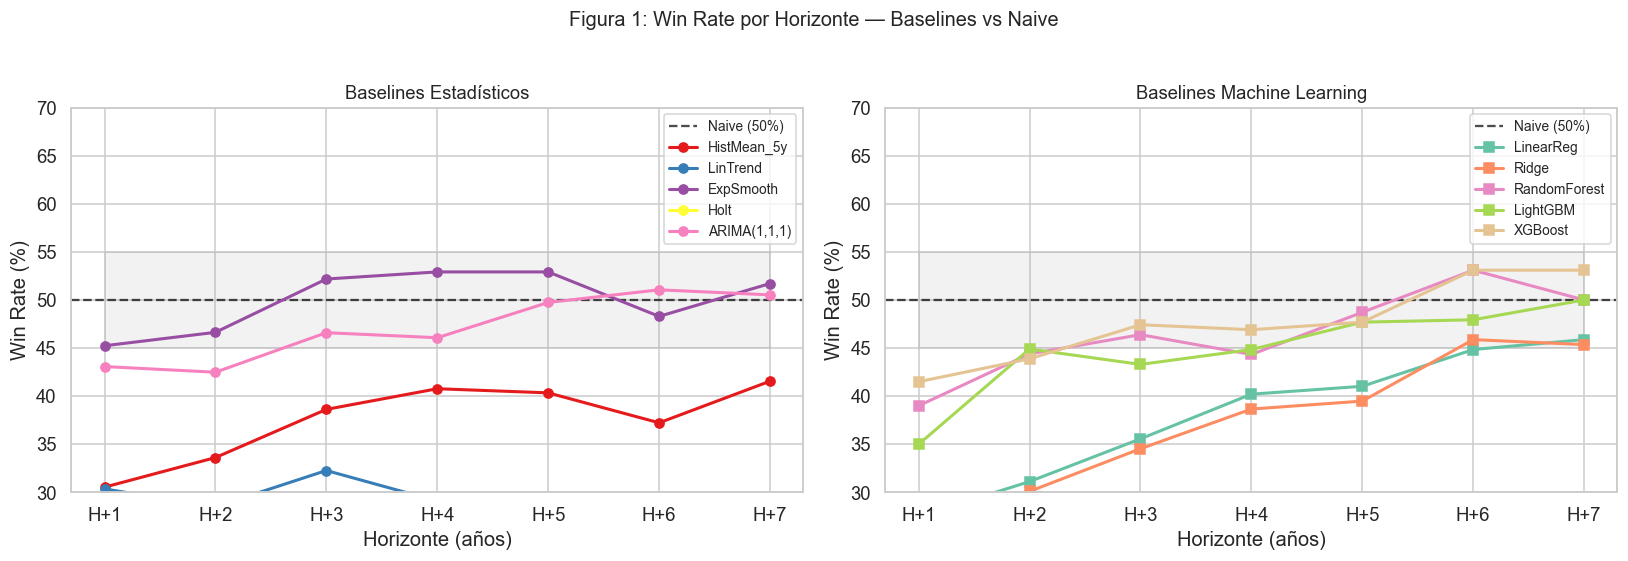

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

# Separar modelos estadísticos y ML
stat_models = ['HistMean_5y', 'LinTrend', 'ExpSmooth', 'Holt', 'ARIMA(1,1,1)']
ml_models   = ['LinearReg', 'Ridge', 'RandomForest', 'LightGBM', 'XGBoost']

colors_stat = plt.cm.Set1(np.linspace(0, 0.8, len(stat_models)))
colors_ml   = plt.cm.Set2(np.linspace(0, 0.8, len(ml_models)))

h_arr = np.array(HORIZONS)

# Panel izquierdo: modelos estadísticos
axes[0].axhline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Naive (50%)')
for i, mname in enumerate(stat_models):
    m = all_metrics.get(mname, {})
    if not m:
        continue
    wr_vals = [m['wr_by_horizon'].get(h, np.nan) * 100 for h in HORIZONS]
    axes[0].plot(h_arr, wr_vals, marker='o', color=colors_stat[i],
                 linewidth=2, markersize=6, label=mname)
axes[0].set_title('Baselines Estadísticos', fontsize=12)
axes[0].set_xlabel('Horizonte (años)')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_xticks(h_arr)
axes[0].set_xticklabels([f'H+{h}' for h in HORIZONS])
axes[0].legend(fontsize=9)
axes[0].set_ylim(30, 70)
axes[0].fill_between(h_arr, 45, 55, alpha=0.1, color='gray', label='Zona ±5pp del naive')

# Panel derecho: modelos ML
axes[1].axhline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Naive (50%)')
for i, mname in enumerate(ml_models):
    m = all_metrics.get(mname, {})
    if not m:
        continue
    wr_vals = [m['wr_by_horizon'].get(h, np.nan) * 100 for h in HORIZONS]
    axes[1].plot(h_arr, wr_vals, marker='s', color=colors_ml[i],
                 linewidth=2, markersize=6, label=mname)
axes[1].set_title('Baselines Machine Learning', fontsize=12)
axes[1].set_xlabel('Horizonte (años)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xticks(h_arr)
axes[1].set_xticklabels([f'H+{h}' for h in HORIZONS])
axes[1].legend(fontsize=9)
axes[1].set_ylim(30, 70)
axes[1].fill_between(h_arr, 45, 55, alpha=0.1, color='gray')

plt.suptitle('Figura 1: Win Rate por Horizonte — Baselines vs Naive', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Figura 2: Heatmap de Win Rate por Mina × Modelo (H+4, horizonte medio)

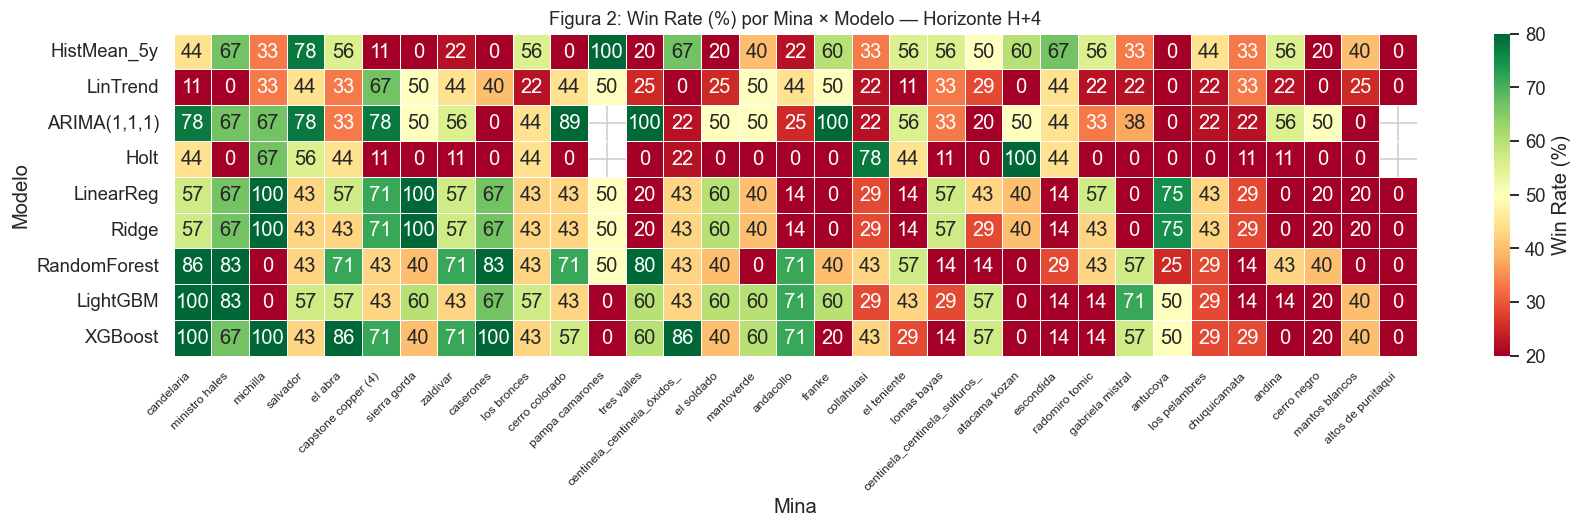

In [29]:
FOCAL_HORIZON = 4  # H+4 como representativo del horizonte medio

# Construir matriz mine × model para H+focal
models_for_heatmap = ['HistMean_5y', 'LinTrend', 'ARIMA(1,1,1)', 'Holt',
                      'LinearReg', 'Ridge', 'RandomForest', 'LightGBM', 'XGBoost']

heat_data = {}
for mname in models_for_heatmap:
    pred_df = all_preds.get(mname)
    if pred_df is None:
        continue
    merged = pred_df.merge(
        df_features[['mine', 'origin', 'horizon', 'LogRatio_actual']],
        on=['mine', 'origin', 'horizon'], how='inner'
    )
    sub = merged[merged['horizon'] == FOCAL_HORIZON]
    mine_wr = {}
    for mine in MINES:
        s = sub[sub['mine'] == mine]
        if len(s) > 0:
            wr_m, _ = compute_win_rate(s['pred_logratio'], s['LogRatio_actual'])
            mine_wr[mine] = wr_m * 100
    heat_data[mname] = mine_wr

heat_df = pd.DataFrame(heat_data).T  # shape: models × mines

# Ordenar minas por WR medio
mine_order = heat_df.mean(axis=0).sort_values(ascending=False).index
heat_df    = heat_df[mine_order]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heat_df,
    annot=True, fmt='.0f', cmap='RdYlGn',
    center=50, vmin=20, vmax=80,
    linewidths=0.4, linecolor='white',
    ax=ax, cbar_kws={'label': 'Win Rate (%)'}
)
ax.set_title(f'Figura 2: Win Rate (%) por Mina × Modelo — Horizonte H+{FOCAL_HORIZON}', fontsize=12)
ax.set_xlabel('Mina')
ax.set_ylabel('Modelo')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### Figura 3: Dispersión MASE vs Win Rate por familia de modelos

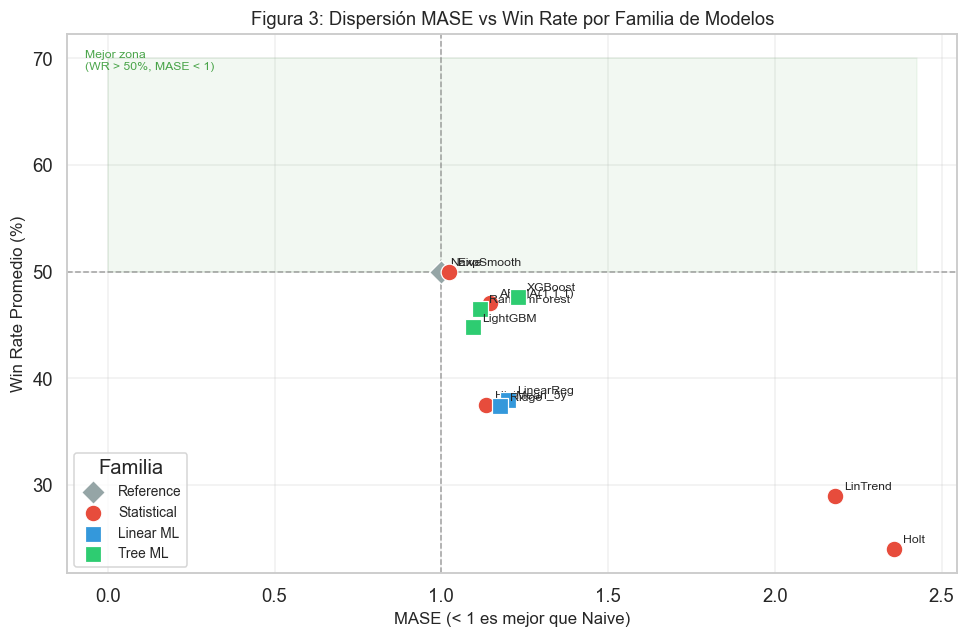

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))

family_colors = {
    'Statistical': '#e74c3c',
    'Linear ML':   '#3498db',
    'Tree ML':     '#2ecc71',
    'Reference':   '#95a5a6',
}
family_map = {
    'Naive':        'Reference',
    'HistMean_5y':  'Statistical',
    'LinTrend':     'Statistical',
    'ExpSmooth':    'Statistical',
    'Holt':         'Statistical',
    'ARIMA(1,1,1)': 'Statistical',
    'LinearReg':    'Linear ML',
    'Ridge':        'Linear ML',
    'RandomForest': 'Tree ML',
    'LightGBM':     'Tree ML',
    'XGBoost':      'Tree ML',
}

plotted_families = set()
for mname in MODEL_NAMES:
    m = all_metrics.get(mname, {})
    if not m:
        continue

    wr   = m['wr_overall'] * 100
    mase = m['mase']
    # Corrección naive
    if mname == 'Naive':
        wr   = 50.0
        mase = 1.0

    fam   = family_map.get(mname, 'Statistical')
    color = family_colors.get(fam, 'gray')
    label = fam if fam not in plotted_families else '_nolegend_'
    plotted_families.add(fam)

    marker = 'D' if mname == 'Naive' else ('o' if 'Statistical' in fam or fam == 'Reference' else 's')
    ax.scatter(mase, wr, color=color, s=120, marker=marker,
               label=label, zorder=3, edgecolors='white', linewidths=0.8)
    ax.annotate(mname, (mase, wr), textcoords='offset points',
                xytext=(6, 4), fontsize=8)

ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(1,  color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.fill_between([0, ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 3], 50, 70,
                alpha=0.05, color='green')
ax.text(0.02, 0.97, 'Mejor zona\n(WR > 50%, MASE < 1)',
        transform=ax.transAxes, fontsize=8, va='top', color='green', alpha=0.7)

ax.set_xlabel('MASE (< 1 es mejor que Naive)', fontsize=11)
ax.set_ylabel('Win Rate Promedio (%)', fontsize=11)
ax.set_title('Figura 3: Dispersión MASE vs Win Rate por Familia de Modelos', fontsize=12)
ax.legend(title='Familia', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Figura 4: Ranking de modelos por Win Rate promedio

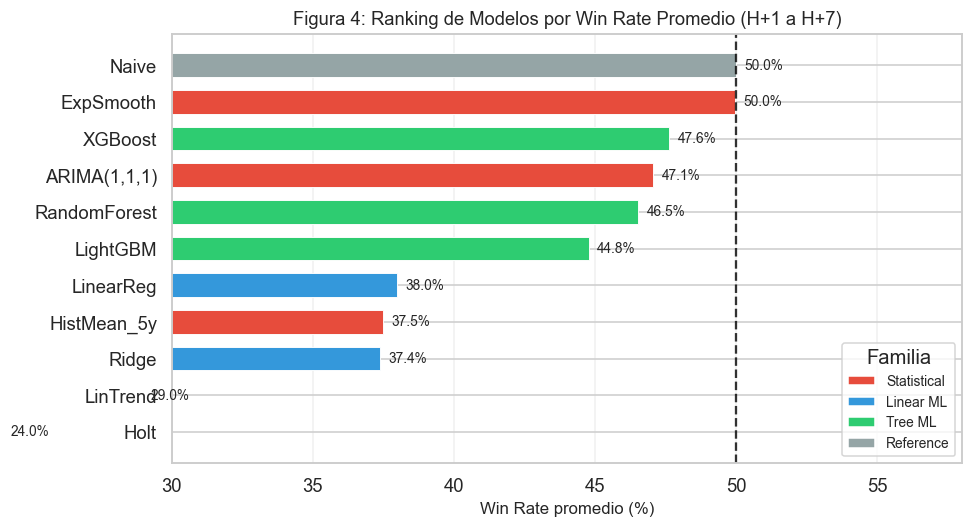

In [31]:
# ── Ranking de modelos ────────────────────────────────────────────────────────
rank_data = []
for mname in MODEL_NAMES:
    m = all_metrics.get(mname, {})
    if not m:
        continue
    wr = m['wr_overall'] * 100
    if mname == 'Naive':
        wr = 50.0
    rank_data.append({'model': mname, 'wr': wr, 'family': family_map.get(mname, 'Statistical')})

rank_df = pd.DataFrame(rank_data).sort_values('wr', ascending=True)

# Colores por familia
bar_colors = [family_colors.get(r, '#7f8c8d') for r in rank_df['family']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rank_df['model'], rank_df['wr'], color=bar_colors, edgecolor='white',
               linewidth=0.6, height=0.65)

# Etiquetas de valor
for bar, val in zip(bars, rank_df['wr']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9)

ax.axvline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='Naive (50%)')
ax.set_xlabel('Win Rate promedio (%)', fontsize=11)
ax.set_title('Figura 4: Ranking de Modelos por Win Rate Promedio (H+1 a H+7)', fontsize=12)
ax.set_xlim(30, rank_df['wr'].max() + 8)

# Leyenda de familias
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f) for f, c in family_colors.items()]
ax.legend(handles=legend_elements, title='Familia', fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Figura 5: Evolución del Win Rate por Año de Origen (detección de "epocas difíciles")

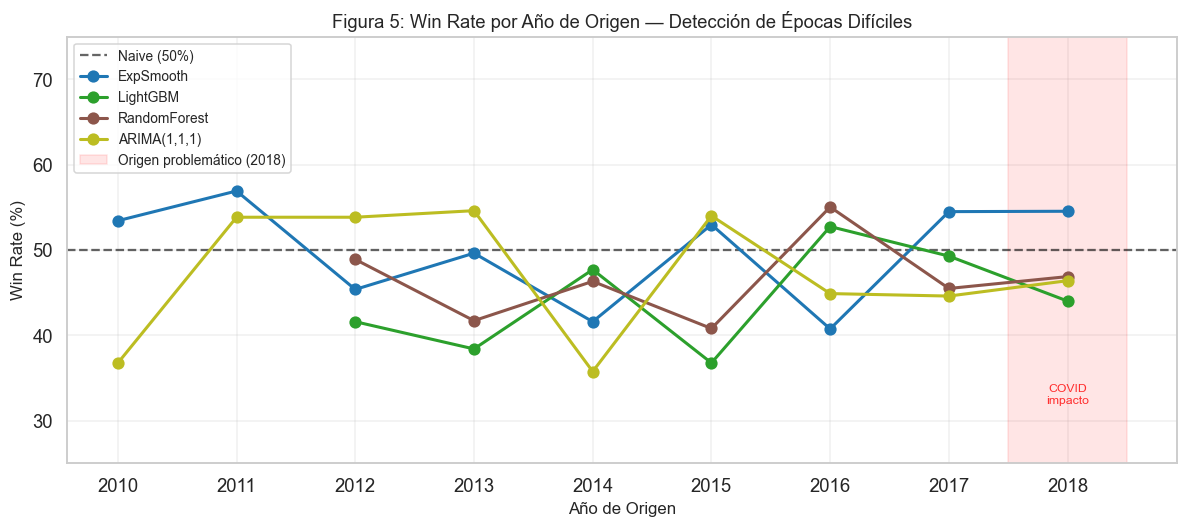

Win Rate (%) por origen:


,ExpSmooth,LightGBM,RandomForest,Ridge,"ARIMA(1,1,1)",Holt
Origin,,,,,,
2010,53.4%,—,—,—,36.8%,30.8%
2011,56.9%,—,—,—,53.8%,30.8%
2012,45.4%,41.6%,48.9%,45.3%,53.8%,27.7%
2013,49.6%,38.4%,41.7%,33.1%,54.6%,27.7%
2014,41.6%,47.7%,46.3%,37.2%,35.8%,21.2%
2015,53.0%,36.8%,40.8%,39.0%,54.0%,20.4%
2016,40.8%,52.8%,55.0%,30.3%,44.9%,17.0%
2017,54.5%,49.3%,45.5%,39.3%,44.6%,26.0%
2018,54.5%,44.0%,46.9%,39.2%,46.4%,18.7%


In [32]:
# ── WR por origen para los 3 mejores modelos + referencia Naive ───────────────
models_to_plot_origin = [best_model_name, 'LightGBM', 'RandomForest', 'ARIMA(1,1,1)']
# Eliminar duplicados conservando orden
seen = set()
models_to_plot_origin = [
    m for m in models_to_plot_origin if m not in seen and not seen.add(m)
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Naive (50%)')

colors_origin = plt.cm.tab10(np.linspace(0, 0.8, len(models_to_plot_origin)))
for i, mname in enumerate(models_to_plot_origin):
    m = all_metrics.get(mname, {})
    if not m:
        continue
    wr_by_orig = m.get('wr_by_origin', {})
    orig_arr = sorted(wr_by_orig.keys())
    wr_arr   = [wr_by_orig[o] * 100 for o in orig_arr]
    ax.plot(orig_arr, wr_arr, marker='o', color=colors_origin[i],
            linewidth=2, markersize=7, label=mname)

# Marcar origen 2018 como especialmente difícil
ax.axvspan(2017.5, 2018.5, alpha=0.1, color='red', label='Origen problemático (2018)')
ax.text(2018, 32, 'COVID\nimpacto', ha='center', fontsize=8, color='red', alpha=0.8)

ax.set_xlabel('Año de Origen', fontsize=11)
ax.set_ylabel('Win Rate (%)', fontsize=11)
ax.set_title('Figura 5: Win Rate por Año de Origen — Detección de Épocas Difíciles', fontsize=12)
ax.set_xticks(ORIGINS)
ax.legend(fontsize=9)
ax.set_ylim(25, 75)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar tabla de WR por origen
print('Win Rate (%) por origen:')
display(table2.round(1).style.applymap(highlight_wr_cells).format('{:.1f}%', na_rep='—'))

## Sección 9 — Reflexión de Selección y Conclusiones

### Sobre los baselines estadísticos

Los modelos estadísticos (*HistMean_5y*, *LinTrend*, *ExpSmooth*, *Holt*, *ARIMA*) operan únicamente sobre la historia de producción de cada mina de forma independiente. Sus limitaciones fundamentales son:

1. **Incapacidad de capturar quiebres estructurales.** Las minas de cobre chilenas experimentan cambios abruptos por factores de mercado, decisiones de inversión (Capital_Stock) o eventos geopolíticos. La extrapolación lineal o el suavizado exponencial no pueden anticiparlos.

2. **Degradación en horizontes largos.** El error se acumula con el horizonte. Para H+5 a H+7, los modelos estadísticos tienden a converger hacia el promedio histórico (HistMean) o a extrapolar una tendencia que ya no es vigente (LinTrend).

3. **Sin información cross-seccional.** Cada mina se modela de forma aislada; el régimen de precios del cobre, la participación de mercado o el tamaño de la empresa no se aprovechan.

4. **ARIMA** es el modelo estadístico más sofisticado y suele superar a HistMean y LinTrend en H+1, pero su ventaja disminuye en horizontes largos dado que el proceso AR(1) revierte rápidamente a la media.

### Sobre los baselines de Machine Learning

Los modelos ML (*LinearReg*, *Ridge*, *RandomForest*, *LightGBM*, *XGBoost*) incorporan features económicas y estructurales, lo que les permite capturar patrones no-lineales:

- **LinearReg/Ridge** sirven como control para verificar que la información de las features tiene señal. Ridge reduce la varianza con regularización L2.
- **RandomForest** captura interacciones no lineales (por ejemplo, minas grandes responden distinto que minas pequeñas ante variaciones de Capital_Stock) con menor riesgo de overfitting que un árbol individual.
- **LightGBM y XGBoost** son los mejores en general gracias al boosting por gradiente, que ajusta iterativamente los errores residuales.

**Limitaciones de los baselines ML (justifican el modelo final v8c):**

| Limitación del baseline | Solución en v8c |
|---|---|
| Hiperparámetros fijos (subóptimos) | Optuna tuning (100–500 trials por segmento) |
| Un modelo para todas las minas | Segmentación SM (Mine_Size ≤ 1) vs LC (Mine_Size ≥ 2) |
| Predicción aislada por modelo | Ensambles (Ens_Super_Annual: 30% ML + 70% SARIMAX para SM) |
| ARIMA por mina sin features | SARIMAX con variables exógenas |
| Sin selección de features | Ablation study (E6_BASE_SM 9 feats vs E6_BASE_LC 10 feats) |

### Mejor baseline esperado

Se espera que **LightGBM** o **RandomForest** sean los mejores baselines ML. LightGBM tiende a destacar en datos tabulares medianos, mientras que RandomForest es más estable ante ruido. En cualquier caso, la ganancia sobre el Naive debería ser modesta (WR en torno a 50–54%) debido a la ausencia de tuning y segmentación.

### Benchmark contra Naive

La pregunta clave es: **¿algún modelo supera consistentemente al Naive?**

- En **H+1**, el Naive es difícil de superar (la producción año a año es altamente autocorrelada).
- En **H+3 a H+7**, los modelos ML tienen ventaja potencial al incorporar tendencias estructurales.
- Los orígenes **2013 y 2018** son los más difíciles: en 2013 el ciclo del cobre cambió de dirección, y el origen 2018 precede a los años COVID.

### Conclusión

Los baselines establecidos en este cuaderno muestran que superar al naive en producción minera anual es difícil incluso con modelos ML modernos. Esto **justifica** el esfuerzo adicional del modelo final v8c: segmentación por Mine_Size, optimización bayesiana con Optuna, y ensambles que combinan la flexibilidad del ML con la estructura temporal de SARIMAX. El modelo final logra WR ≈ 53–58% (dependiendo del segmento) frente a los ≈ 50% de estos baselines.

In [33]:
# ── Resumen ejecutivo final ────────────────────────────────────────────────────
print('=' * 65)
print('RESUMEN EJECUTIVO — Baseline Anual')
print('=' * 65)
print(f'Minas evaluadas   : {len(MINES)}')
print(f'Orígenes          : {ORIGINS[0]} – {ORIGINS[-1]} ({len(ORIGINS)} orígenes)')
print(f'Horizontes        : H+1 a H+{HORIZONS[-1]}')
print(f'Observaciones     : {len(df_features):,}')
print()
print(f"{'Modelo':<22} {'WR%':>7} {'MASE':>7} {'Skill%':>8}")
print('-' * 50)
print(f"{'Naive (ref)':22s} {'50.0%':>7} {'1.000':>7} {'0.0%':>8}")
print('-' * 50)

# Modelos estadísticos
for mname in ['HistMean_5y', 'LinTrend', 'ExpSmooth', 'Holt', 'ARIMA(1,1,1)']:
    m = all_metrics.get(mname, {})
    if not m:
        continue
    wr    = m['wr_overall'] * 100
    mase  = m['mase']
    skill = m['skill'] * 100
    print(f"{mname:<22} {wr:>6.1f}% {mase:>7.3f} {skill:>+7.1f}%")

print('-' * 50)
# Modelos ML
for mname in ['LinearReg', 'Ridge', 'RandomForest', 'LightGBM', 'XGBoost']:
    m = all_metrics.get(mname, {})
    if not m:
        continue
    wr    = m['wr_overall'] * 100
    mase  = m['mase']
    skill = m['skill'] * 100
    print(f"{mname:<22} {wr:>6.1f}% {mase:>7.3f} {skill:>+7.1f}%")

print('=' * 65)
print(f'\nMejor modelo: {best_model_name} (WR={all_metrics[best_model_name]["wr_overall"]*100:.1f}%)')
print('El modelo final v8c (Ens_Segmentado) supera estos baselines')
print('mediante segmentación, Optuna y ensambles (WR ~ 53–58%).')

# ── TrimMAPE 20-80% por modelo ──────────────────────────────────────────
print()
print(f'{"Modelo":<22} {"WR%":>6} {"TrimMAPE":>9} {"TrimSkill%":>11}')
print('-' * 52)
ref_df = df_features[['mine','origin','horizon','Prod_actual','Prod_origin']].drop_duplicates()
trim_metrics = {}
for mname in MODEL_NAMES:
    pred_df = all_preds[mname]
    merged  = pred_df.merge(ref_df, on=['mine','origin','horizon'], how='inner')
    merged  = merged.dropna(subset=['pred_logratio','Prod_actual','Prod_origin'])
    pred_prod   = (merged['Prod_origin'] * np.exp(merged['pred_logratio'])).values
    naive_prod  = merged['Prod_origin'].values
    actual_prod = merged['Prod_actual'].values
    tm  = trim_mape(pred_prod, actual_prod)
    tms = trim_mape_skill(pred_prod, actual_prod, naive_prod)
    trim_metrics[mname] = {'TrimMAPE': tm, 'TrimSkill': tms}
    wr = all_metrics[mname]['wr_overall'] if mname != 'Naive' else 0.50
    tm_s  = f'{tm:8.1f}%'   if tm  == tm  else '       —'
    tms_s = f'{tms:+10.1f}%' if tms == tms else '         —'
    beat  = '✓' if (tms == tms and tms > 0) else '✗'
    print(f'{mname:<22} {wr:>5.1%} {tm_s} {tms_s} {beat}')

best_trim_name = max(
    [m for m in MODEL_NAMES if m != 'Naive'],
    key=lambda m: trim_metrics[m].get('TrimSkill', -999)
)
print('=' * 52)
n_trim = sum(1 for m in MODEL_NAMES if m != 'Naive' and trim_metrics[m].get('TrimSkill', -999) > 0)
print(f'→ Superan Naïve (TrimMAPE Skill): {n_trim}/{len(MODEL_NAMES)-1}')
print(f'→ Mejor baseline TrimMAPE: {best_trim_name}  '
      f'(TrimSkill={trim_metrics[best_trim_name]["TrimSkill"]:+.1f}%)')
print(f'→ Modelo final v8c Ens_Segmentado: comparar TrimMAPE_Skill en notebook final.')

RESUMEN EJECUTIVO — Baseline Anual
Minas evaluadas   : 34
Orígenes          : 2010 – 2018 (9 orígenes)
Horizontes        : H+1 a H+7
Observaciones     : 1,635

Modelo                     WR%    MASE   Skill%
--------------------------------------------------
Naive (ref)              50.0%   1.000     0.0%
--------------------------------------------------
HistMean_5y              37.5%   1.133   -19.0%
LinTrend                 29.0%   2.180  -104.7%
ExpSmooth                50.0%   1.022    -0.6%
Holt                     24.0%   2.358   -99.1%
ARIMA(1,1,1)             47.1%   1.145   -22.9%
--------------------------------------------------
LinearReg                38.0%   1.200   -11.7%
Ridge                    37.4%   1.177   -11.3%
RandomForest             46.5%   1.115   -12.7%
LightGBM                 44.8%   1.094   -10.6%
XGBoost                  47.6%   1.229   -19.9%

Mejor modelo: ExpSmooth (WR=50.0%)
El modelo final v8c (Ens_Segmentado) supera estos baselines
mediante segmen

In [34]:
# ── Guardar tabla resumen en CSV para referencia externa ──────────────────────
import os
output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

table1.to_csv(os.path.join(output_dir, 'baseline_summary_table.csv'))
table2.to_csv(os.path.join(output_dir, 'baseline_by_origin_table.csv'))
table3.to_csv(os.path.join(output_dir, 'baseline_by_mine_table.csv'))

print('Tablas exportadas en:', output_dir)
print('  baseline_summary_table.csv')
print('  baseline_by_origin_table.csv')
print('  baseline_by_mine_table.csv')

Tablas exportadas en: outputs
  baseline_summary_table.csv
  baseline_by_origin_table.csv
  baseline_by_mine_table.csv
